In [1]:
"""
SHARED FIGURE STYLE -- run this cell first
=========================================
Colours, panel sizes, type and saving all come from paper-individuality/paper_style.py,
so this notebook's figures match every other figure in the paper and the poster.
Nothing below hardcodes a hex colour or a point size; switching mode re-renders the
whole notebook:

    ps.use('poster')   big type, big panels -- what a poster needs
    ps.use('paper')    journal column widths, 7 pt type

`session_filters` sits next to this notebook, so its folder goes on the path too --
that way the notebook also runs from a different working directory.
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import importlib
import paper_style
importlib.reload(paper_style)   # kernels cache modules: without this, edits to
ps = paper_style                # paper_style stay invisible until a restart
ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

In [2]:
"""
SYLLABLE CORRELATIONS ACROSS THE TRIAL
======================================
The question here is not the LDA one. For each SYLLABLE and each MOMENT IN THE
TRIAL, are the differences between mice seen in the proficient state already
present earlier in training?

At every (trial bin, syllable) the mice's proficient values are correlated
against their values at an earlier timepoint. r is therefore a correlation
ACROSS MICE computed separately at each moment of the trial:
    r ~ 1  the mice keep their rank order for that syllable at that moment
    r ~ 0  the individual differences there are unrelated to the proficient ones

Two things get plotted together:
  * the cross-timepoint r (Early / Late / Pre-rec vs Proficient);
  * the within-proficient SPLIT-HALF reliability, which is the ceiling. No
    cross-timepoint correlation can exceed how reproducible the measure is
    between two halves of a mouse's own proficient sessions, so a low r next to
    a low ceiling means "noisy measure", not "individuality was not there yet".

Loading is deliberately identical to lda_trajectories.ipynb -- same files, same
QC exclusions, same binarise/reconstruct convention -- so the two notebooks
describe the same data. Only the analysis differs.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
from matplotlib.lines import Line2D
from scipy.stats import rankdata
import seaborn as sns

BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
]
base_path = next((p for p in BASE_CANDIDATES if os.path.isdir(p)), BASE_CANDIDATES[0])
print('base_path:', base_path)


def filter_sequences(all_sequences, min_sessions=1):
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    session_count = (all_sequences[['mouse_name', 'session']].drop_duplicates()
                     .groupby(['mouse_name'])['session'].count().reset_index())
    keep = session_count.loc[session_count['session'] >= min_sessions, 'mouse_name']
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(keep)].reset_index(drop=True)
    return all_sequences


def binarize(use_sequences, n_paw_states=8, keep_paw=True, keep_whisk=True, keep_lick=True):
    """Integer syllable codes -> per-timestep indicators (as in lda_trajectories)."""
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type must be kept.")
    n_raw = n_paw_states + 2
    n_trials, timesteps = use_sequences.shape
    binarized = np.zeros((n_trials, timesteps * n_raw))
    for t in range(timesteps):
        vals = use_sequences[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int)
        start = t * n_raw
        if len(labels):
            rows = np.arange(n_trials)[valid]
            binarized[rows, start + (labels % n_paw_states)] = 1
            binarized[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            binarized[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            binarized[nan_mask, start:start + n_raw] = np.nan
    cols = []
    if keep_paw:   cols += [i for i in range(n_paw_states) if i != 1]
    if keep_whisk: cols += [n_paw_states]
    if keep_lick:  cols += [n_paw_states + 1]
    all_cols = [t * n_raw + c for t in range(timesteps) for c in cols]
    return binarized[:, all_cols]


def build_multi_timepoint(files_by_label, keep_paw=True, keep_whisk=True, keep_lick=True,
                          min_sessions_by_label=None, exclude_by_label=None):
    """One session-level design matrix with a timepoint label per row."""
    min_sessions_by_label = min_sessions_by_label or {}
    exclude_by_label = exclude_by_label or {}
    frames = []
    for label, path in files_by_label.items():
        seq = pd.read_parquet(path)
        seq['session'] = seq['sample'].str[:36]
        n0 = seq['session'].nunique()
        seq = filter_sequences(seq, min_sessions=min_sessions_by_label.get(label, 1))
        n1 = seq['session'].nunique()
        drop = list(exclude_by_label.get(label, []))
        if drop:
            seq = seq.loc[~seq['session'].isin(drop)]
        n2 = seq['session'].nunique()
        print(f"  {label:11s} {n0:4d} sessions -> {n1:4d} after prob_sessions/min_sessions"
              f" -> {n2:4d} after the {label} exclusion list ({n0-n1} + {n1-n2} dropped)")
        seq['timepoint'] = label
        frames.append(seq)
    allseq = pd.concat(frames)

    design = (allseq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type', 'timepoint'],
                           columns=['broader_label'], values='binned_sequence')
              .reset_index().dropna())
    if 'index' in design.columns:
        design = design.drop(columns=['index'])
    design = design.sort_values(by=['timepoint', 'session'])
    assert len(design) > 0, "design is empty after filtering"

    epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    seqs = np.vstack(design[epoch_to_analyse].apply(lambda r: np.hstack(r), axis=1))
    feats = binarize(seqs, n_paw_states=8, keep_paw=keep_paw,
                     keep_whisk=keep_whisk, keep_lick=keep_lick)

    tmp = pd.DataFrame(feats)
    tmp['session'] = design['session'].values
    per_session = tmp.groupby('session', sort=False)[np.arange(feats.shape[1])].mean()

    bad = per_session.isna().any(axis=0)
    if bad.sum():
        print(f"!! dropping {int(bad.sum())} features that are NaN for some session")
        per_session = per_session.loc[:, ~bad]

    meta = design[['session', 'mouse_name', 'timepoint']].drop_duplicates().set_index('session')
    meta = meta.reindex(per_session.index)
    print(f"OK {len(per_session)} sessions, {per_session.shape[1]} features, "
          f"{meta.mouse_name.nunique()} mice")
    print(meta.groupby('timepoint').agg(sessions=('mouse_name', 'size'),
                                        mice=('mouse_name', 'nunique')).to_string())
    return (np.asarray(per_session), meta['mouse_name'].values,
            meta['timepoint'].values, np.asarray(per_session.index))


N_PAW_STATES = 8


def reconstruct_syllables(Xmat, n_paw_states=N_PAW_STATES):
    """(n_sessions, n_features) -> (n_sessions, n_bins, n_paw_states + 2), paw 1 restored.
    Feature order out: paw0..paw7, whisk, lick."""
    npf = n_paw_states - 1 + 2
    assert Xmat.shape[1] % npf == 0, (
        f"{Xmat.shape[1]} features is not a multiple of {npf}; are keep_paw/"
        f"keep_whisk/keep_lick all True?")
    T = Xmat.shape[1] // npf
    R = Xmat.reshape(-1, T, npf)
    paw7 = R[:, :, :n_paw_states - 1]
    omitted = 1 - paw7.sum(axis=2)
    full = np.zeros((Xmat.shape[0], T, n_paw_states + 2))
    full[:, :, 0] = paw7[:, :, 0]
    full[:, :, 1] = omitted
    full[:, :, 2:n_paw_states] = paw7[:, :, 1:]
    full[:, :, n_paw_states] = R[:, :, n_paw_states - 1]
    full[:, :, n_paw_states + 1] = R[:, :, n_paw_states]
    return full


base_path: /home/ines/repositories/representation_learning_variability/paper-individuality/data/


In [3]:
""" CONFIG AND BUILD (same choices as lda_trajectories) """
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint

QC_STRICTNESS = 'filtered_out'
EXCLUDE_BY_LABEL = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = EXCLUDE_BY_LABEL['Proficient']
print(f"exclusions from the sheet ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in EXCLUDE_BY_LABEL.items()))

BIN = '8_k_10_bin'
FILES = {
    'Early':       base_path + f'training/paw_wheel_session_1_{BIN}_syllables_04-09-2026',
    'Late':        base_path + f'training/paw_wheel_last_training_{BIN}_syllables_04-09-2026',
    'Pre-rec':     base_path + f'training/paw_wheel_biased_{BIN}_syllables_04-09-2026',
    'Proficient':  base_path + f'paw_wheel_{BIN}_syllables_28-08-2026',
}
ALL_ORDER = list(ps.TIMEPOINT_ORDER)
COLORS = dict(ps.TIMEPOINT)          # magma ramp, darkening Early -> Proficient;
                                     # shared with every other figure in the paper

for lab, f in FILES.items():
    print(('  OK  ' if os.path.exists(f) else '  MISSING '), lab, os.path.basename(f))

X, mice, timepoint, sessions = build_multi_timepoint(FILES, exclude_by_label=EXCLUDE_BY_LABEL)

recon = reconstruct_syllables(X)                 # (n_sessions, n_bins, 10)
N_BINS = recon.shape[1]
EPOCH_EDGES = [N_BINS // 4, N_BINS // 2, 3 * N_BINS // 4]
EPOCH_NAMES = list(ps.EPOCH_NAMES)
FEATURE_NAMES = list(ps.SYLLABLE_NAMES)      # Paw 0..7, Whisk, Lick
FEATURE_COLORS = list(ps.SYLLABLE_COLORS)    # Set3 paws (as in lda_trajectories),
                                             # grey whisk, near-black lick
MODALITIES = dict(ps.MODALITY)
print(f"reconstructed: {recon.shape[0]} sessions x {N_BINS} trial bins x "
      f"{recon.shape[2]} features (paw 1 restored)")

exclusions from the sheet (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12
  OK   Early paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
  OK   Late paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026
  OK   Pre-rec paw_wheel_biased_8_k_10_bin_syllables_04-09-2026
  OK   Proficient paw_wheel_8_k_10_bin_syllables_28-08-2026
  Early         47 sessions ->   47 after prob_sessions/min_sessions ->   37 after the Early exclusion list (0 + 10 dropped)
  Late          55 sessions ->   55 after prob_sessions/min_sessions ->   49 after the Late exclusion list (0 + 6 dropped)
  Pre-rec      116 sessions ->  116 after prob_sessions/min_sessions ->   96 after the Pre-rec exclusion list (0 + 20 dropped)
  Proficient   332 sessions ->  330 after prob_sessions/min_sessions ->  330 after the Proficient exclusion list (2 + 0 dropped)
OK 512 sessions, 360 features, 101 mice
            sessions  mice
timepoint                 
Early             37    37
Late              49    49
Pre-r

In [4]:
"""
PLOTTING FURNITURE -- one place for everything the figures below share
=====================================================================
All of it comes from paper_style, so a figure drawn here matches the LDA figures and
the rest of the poster. Three conventions are worth knowing before reading the code:

  * NO LITERAL SIZES. Panel sizes are fractions of the current mode's 'single' panel
    (`panels`) and every font size is a fraction of the mode's base size (`small`), so
    ps.use('paper') in the header cell rescales the whole notebook at once.
  * THE LONG EXPLANATORY SUPTITLES ARE OFF by default (DRAW_NOTES). At poster type a
    three-line note is unreadable, and on a poster that text belongs in the caption.
    Set DRAW_NOTES = True to get them back while exploring in the notebook.
  * A CORRELATION PANEL SHOWS ITS STATS INSIDE THE AXES (annotate_rho) and draws its
    regression line only when the correlation is significant (ps.regline) -- the
    paper's convention, since a line through a null result reads as a trend whatever
    the caption says.
"""
shade = ps.shade                     # same hue, deeper the nearer the timepoint
TP_LABEL = dict(ps.TIMEPOINT_LABEL)  # 'Early' -> 'Early learning'

# The two variance components in the boundary diagnostic are drawn in the poles of the
# correlation colormap -- teal = between mice, brown = within mouse -- so the reader
# meets the same two colours in the maps and in the curves.
VAR_COLOR = {'between': '#11736B', 'within': '#8C5A1A'}

DRAW_NOTES = False


def small(f=0.85):
    """A font size relative to the mode's base size -- never a hardcoded number."""
    return plt.rcParams['font.size'] * f


def note(fig, text):
    """The explanatory figure note: drawn only when DRAW_NOTES is on."""
    if DRAW_NOTES:
        fig.suptitle(text, fontsize=small(0.9))


def panel_title(ax, text, above_epochs=False, **kw):
    """A panel title. above_epochs lifts it clear of the epoch names that
    ps.epoch_lines(label=True) writes just above the axes -- without it the title and
    'Quiescence' land on the same line."""
    kw.setdefault('pad', plt.rcParams['axes.titlepad'] + (small(1.6) if above_epochs else 0))
    return ax.set_title(text, **kw)


def panels(nrow=1, ncol=1, w=1.0, h=1.0, **kw):
    """plt.subplots with the panel size expressed in units of the mode's 'single'
    panel: panels(1, 3, w=0.9) is three panels, each 0.9 of a single panel wide."""
    pw, ph = ps.FIG['single']
    return plt.subplots(nrow, ncol, figsize=(pw * w * ncol, ph * h * nrow), **kw)


def annotate_rho(ax, rho, p, n=None, loc='upper left', **kw):
    """The stats block inside the panel, placed as ps.annotate_corr places it -- but
    labelled rho, because every correlation in this notebook is a Spearman (METHOD)
    and calling it r in the figure would be wrong. Asterisks follow ps.stars."""
    x, ha = (0.04, 'left') if 'left' in loc else (0.96, 'right')
    y, va = (0.97, 'top') if 'upper' in loc else (0.04, 'bottom')
    txt = f"ρ = {rho:.2f}\np = {p:.1e} {ps.stars(p) if p < 0.05 else 'n.s.'}"
    if n is not None:
        txt += f"\nn = {n}"
    kw.setdefault('fontsize', small())
    kw.setdefault('color', '0.2')
    kw.setdefault('linespacing', 1.25)
    return ax.text(x, y, txt, transform=ax.transAxes, ha=ha, va=va, zorder=5, **kw)

In [5]:
"""
CORRELATIONS ACROSS MICE, PER (TRIAL BIN, SYLLABLE)
===================================================
Sessions are averaged within a mouse first, so a mouse with 6 proficient sessions
does not count six times. Every correlation uses only the mice present at BOTH
timepoints being compared, and n is reported per pair because it differs.

The Fisher band is the 95% interval for r itself (z +/- 1.96/sqrt(n-3)); it is a
precision statement, not a test against the alternative timepoints.
"""
REF = 'Proficient'
TPS = ['Early', 'Late', 'Pre-rec']          # compared against REF, ordered far -> near
METHOD = 'spearman'                          # 'pearson' or 'spearman' (rank, robust to outlier mice)
MIN_STD = 1e-8                               # below this SD across mice, a cell is 'flat'
# WHAT A FLAT CELL SHOULD REPORT. Strictly a correlation with a constant is UNDEFINED,
# not zero. But these cells are flat for a reason -- a movement syllable during the
# enforced quiescence hold, where every mouse sits at exactly 0 -- and "there are no
# individual differences here" is much closer to r = 0 than to a hole in the curve.
# Reporting 0 also keeps the aggregates honest: with NaN those cells are SKIPPED by
# nanmean, which inflates the mean r for precisely the epochs where individuality is
# absent. The flat mask is kept either way so the plots can mark them as not measured.
FLAT_AS_ZERO = True


def profiles_by_mouse(label):
    """(mouse names, (n_mice, n_bins, n_features)) -- sessions averaged within mouse."""
    sel = timepoint == label
    ms = np.unique(mice[sel])
    P = np.stack([recon[sel & (mice == m)].mean(0) for m in ms])
    return ms, P


PROFILES = {lab: profiles_by_mouse(lab) for lab in ALL_ORDER}
for lab in ALL_ORDER:
    print(f"  {lab:11s} {len(PROFILES[lab][0]):3d} mice")


def _corr_along_mice(A, B, method=METHOD, min_std=MIN_STD):
    """A, B: (n_mice, n_bins, n_features) -> (r, flat), both (n_bins, n_features).
    Correlation is taken over the mouse axis independently at every (bin, feature);
    `flat` marks the cells with no variance across mice (see FLAT_AS_ZERO)."""
    A = np.asarray(A, float); B = np.asarray(B, float)
    if method == 'spearman':
        A = rankdata(A, axis=0); B = rankdata(B, axis=0)
    elif method != 'pearson':
        raise ValueError("method must be 'pearson' or 'spearman'")
    Ac = A - A.mean(0); Bc = B - B.mean(0)
    with np.errstate(invalid='ignore', divide='ignore'):
        r = (Ac * Bc).sum(0) / np.sqrt((Ac ** 2).sum(0) * (Bc ** 2).sum(0))
    flat = (A.std(0) < min_std) | (B.std(0) < min_std)
    r[flat] = 0.0 if FLAT_AS_ZERO else np.nan
    return r, flat


def _fisher_ci(r, n, z=1.96):
    """95% CI for r, via the Fisher z transform. n < 4 gives no interval."""
    r = np.asarray(r, float)
    if n < 4:
        return np.full_like(r, np.nan), np.full_like(r, np.nan)
    se = 1.0 / np.sqrt(n - 3)
    zr = np.arctanh(np.clip(r, -0.999999, 0.999999))
    return np.tanh(zr - z * se), np.tanh(zr + z * se)


def corr_vs_ref(label, ref=REF, method=METHOD):
    """r across the mice shared by `label` and `ref`, per (bin, feature)."""
    m_a, A = PROFILES[label]; m_b, B = PROFILES[ref]
    shared = np.intersect1d(m_a, m_b)
    ia = pd.Index(m_a).get_indexer(shared); ib = pd.Index(m_b).get_indexer(shared)
    r, flat = _corr_along_mice(A[ia], B[ib], method=method)
    lo, hi = _fisher_ci(r, len(shared))
    # a flat cell was not estimated, so it gets no interval even though r reads 0
    lo[flat] = np.nan; hi[flat] = np.nan
    return dict(r=r, lo=lo, hi=hi, flat=flat, n=len(shared), mice=shared, label=label)


def split_half_reliability(label=REF, n_splits=200, method=METHOD, seed=0,
                           spearman_brown=False):
    """The ceiling: correlate two random halves of each mouse's own sessions at
    `label`, per (bin, feature), averaged over `n_splits` random splits (in Fisher z,
    so the average is not biased toward 0).

    spearman_brown=True steps the estimate up to the reliability of the FULL session
    average rather than of a half -- the right ceiling if a cross-timepoint r is
    computed from all sessions. It is an extrapolation, so it is off by default."""
    sel = timepoint == label
    idx = {m: np.where(sel & (mice == m))[0] for m in np.unique(mice[sel])}
    ms = [m for m, i in idx.items() if len(i) >= 2]
    if len(ms) < 4:
        print(f"!! only {len(ms)} mice have >= 2 {label} sessions -- no usable ceiling")
        return dict(r=np.full((N_BINS, recon.shape[2]), np.nan), n=len(ms), mice=ms,
                    flat=np.zeros((N_BINS, recon.shape[2]), bool))
    rng = np.random.default_rng(seed)
    zs = []; flat_any = np.zeros((N_BINS, recon.shape[2]), bool)
    for _ in range(n_splits):
        A, B = [], []
        for m in ms:
            i = rng.permutation(idx[m]); h = len(i) // 2
            A.append(recon[i[:h]].mean(0)); B.append(recon[i[h:]].mean(0))
        r, flat = _corr_along_mice(np.stack(A), np.stack(B), method=method)
        flat_any |= flat
        zs.append(np.arctanh(np.clip(r, -0.999999, 0.999999)))
    r = np.tanh(np.nanmean(zs, axis=0))
    if spearman_brown:
        r = 2 * r / (1 + r)
    print(f"ceiling: {len(ms)} mice with >= 2 {label} sessions, {n_splits} splits"
          f"{', Spearman-Brown corrected' if spearman_brown else ''}")
    return dict(r=r, n=len(ms), mice=ms, flat=flat_any)


CORR = {tp: corr_vs_ref(tp) for tp in TPS}
CEIL = split_half_reliability(REF, n_splits=200)

print(f"\nmean r over trial bins ({METHOD}, vs {REF})")
print(f"{'modality':10s} " + " ".join(f"{tp:>10s}" for tp in TPS) + f"{'ceiling':>10s}")
for mod, feats in MODALITIES.items():
    row = [f"{np.nanmean(CORR[tp]['r'][:, feats]):10.3f}" for tp in TPS]
    print(f"{mod:10s} " + " ".join(row) + f"{np.nanmean(CEIL['r'][:, feats]):10.3f}")
print("\nmice shared with " + REF + ": " + ", ".join(f"{tp} n={CORR[tp]['n']}" for tp in TPS))
n_cells = N_BINS * recon.shape[2]
print(f"flat cells (no variance across mice -> r = "
      f"{'0' if FLAT_AS_ZERO else 'NaN'}, no CI): "
      + ", ".join(f"{tp} {int(CORR[tp]['flat'].sum())}/{n_cells}" for tp in TPS))
for tp in TPS:
    fl = CORR[tp]['flat']
    if fl.any():
        eb = np.digitize(np.arange(N_BINS), EPOCH_EDGES)
        where = sorted({(EPOCH_NAMES[eb[b]], FEATURE_NAMES[j]) for b, j in zip(*np.where(fl))})
        print(f"   {tp}: " + "; ".join(f"{e} / {f}" for e, f in where))


  Early        37 mice
  Late         49 mice
  Pre-rec      37 mice
  Proficient  101 mice
ceiling: 76 mice with >= 2 Proficient sessions, 200 splits

mean r over trial bins (spearman, vs Proficient)
modality        Early       Late    Pre-rec   ceiling
Paw             0.053      0.148      0.523     0.607
Whisk           0.210      0.324      0.663     0.775
Lick            0.239      0.331      0.669     0.787

mice shared with Proficient: Early n=37, Late n=49, Pre-rec n=37
flat cells (no variance across mice -> r = 0, no CI): Early 3/400, Late 4/400, Pre-rec 2/400
   Early: Quiescence / Paw 6
   Late: Quiescence / Paw 6
   Pre-rec: Quiescence / Paw 6


wrote figures/sylcorr_by_modality_poster_14-09-2026.png, figures/sylcorr_by_modality_poster_14-09-2026.svg


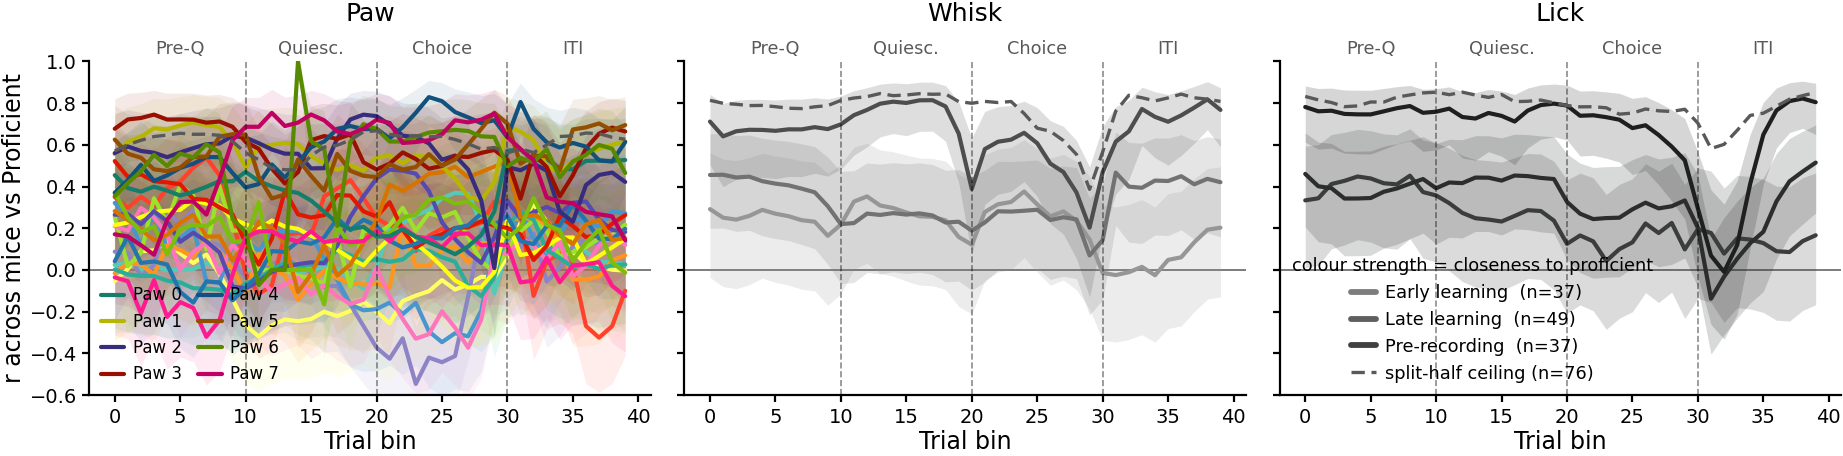

In [6]:
"""
THE FIGURE: one panel per modality, colour intensity = distance from proficient
==============================================================================
Hue identifies the syllable (the 8 paw states get their own colours; whisk and
lick are one line each). Intensity identifies the timepoint: the closer in time
to the proficient state, the stronger the colour, so a family of pale-to-strong
lines of the same hue is one syllable tracked back through learning.

The dashed grey line is the within-proficient split-half ceiling for that panel
(mean over the panel's syllables). Read every coloured line RELATIVE to it.

Colours, panel size, type and export come from paper_style (see the furniture cell),
so this is the same figure at poster or journal size depending only on ps.use().
"""
DISTANCE = {'Pre-rec': 1, 'Late': 2, 'Early': 3}     # steps back from Proficient


def tp_weight(tp, tps, floor=0.32):
    """Colour strength from temporal distance: nearest timepoint = 1, furthest = floor.
    The darkening itself is ps.shade -- it darkens rather than washes out, because Set3
    is already pastel and lightening those further would make the far timepoints
    invisible."""
    d = np.array([DISTANCE.get(t, i + 1) for i, t in enumerate(tps)], float)
    if d.max() == d.min():
        return 1.0
    return float(1 - (1 - floor) * (DISTANCE.get(tp, 1) - d.min()) / (d.max() - d.min()))


def _epoch_furniture(ax, label_epochs=False):
    """Trial-epoch boundaries and the zero line, drawn the paper's way in every panel.
    The epoch names are the abbreviated ones (ps.EPOCH_SHORT): the full four do not
    fit above a panel this wide at poster type -- they run into each other."""
    ps.epoch_lines(ax, N_BINS, label=label_epochs, names=ps.EPOCH_SHORT)
    ps.zero_line(ax)


def plot_correlation_by_modality(tps=None, features=None, show_ceiling=True,
                                 show_ci=True, ylim=(-0.6, 1.0), w=0.9, h=1.0,
                                 save=None):
    """features: restrict the paw panel to a subset, e.g. ['Paw 0', 'Paw 3'], when
    all eight at three intensities is too much to read."""
    ps.reapply()
    tps = list(TPS if tps is None else tps)
    keep = None if features is None else {FEATURE_NAMES.index(f) for f in features}
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']
    fig, axes = panels(1, len(MODALITIES), w=w, h=h, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (mod, feats) in zip(axes, MODALITIES.items()):
        feats = feats if keep is None else [j for j in feats if j in keep] or feats
        # bands stay faint where many lines share a panel, or the paw panel turns to mush
        ci_alpha = 0.18 if len(feats) == 1 else 0.09
        for tp in tps:
            wt = tp_weight(tp, tps)
            for j in feats:
                col = shade(FEATURE_COLORS[j], wt)
                ax.plot(bins, CORR[tp]['r'][:, j], color=col, lw=lw,
                        label=FEATURE_NAMES[j] if tp == tps[-1] else None)
                if show_ci:
                    ax.fill_between(bins, CORR[tp]['lo'][:, j], CORR[tp]['hi'][:, j],
                                    color=col, alpha=ci_alpha, lw=0)
        if show_ceiling:
            ax.plot(bins, np.nanmean(CEIL['r'][:, feats], axis=1), color='0.35',
                    ls=(0, (4, 2)), lw=lw * 0.8, zorder=5)
        _epoch_furniture(ax, label_epochs=True)
        ax.set_xlabel('Trial bin')
        panel_title(ax, mod, above_epochs=True)
        ax.set_ylim(*ylim)
    axes[0].set_ylabel(f'r across mice vs {REF}')
    axes[0].legend(fontsize=small(0.75), ncol=2, loc='lower left')

    # second legend: what the intensity means
    handles = [Line2D([], [], color=shade('#9a9a9a', tp_weight(t, tps)), lw=lw * 1.4,
                      label=f"{TP_LABEL.get(t, t)}  (n={CORR[t]['n']})") for t in tps]
    if show_ceiling:
        handles.append(Line2D([], [], color='0.35', ls=(0, (4, 2)), lw=lw * 0.8,
                              label=f"split-half ceiling (n={CEIL['n']})"))
    axes[-1].legend(handles=handles, fontsize=small(0.8), loc='lower left',
                    title='colour strength = closeness to proficient',
                    title_fontsize=small(0.8))
    note(fig, 'do the between-mouse differences of the proficient state exist earlier?\n'
              f'correlation across mice at each trial bin, per syllable ({METHOD})')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_modality = plot_correlation_by_modality(save='sylcorr_by_modality')

wrote figures/sylcorr_grid_modality_poster_14-09-2026.png, figures/sylcorr_grid_modality_poster_14-09-2026.svg


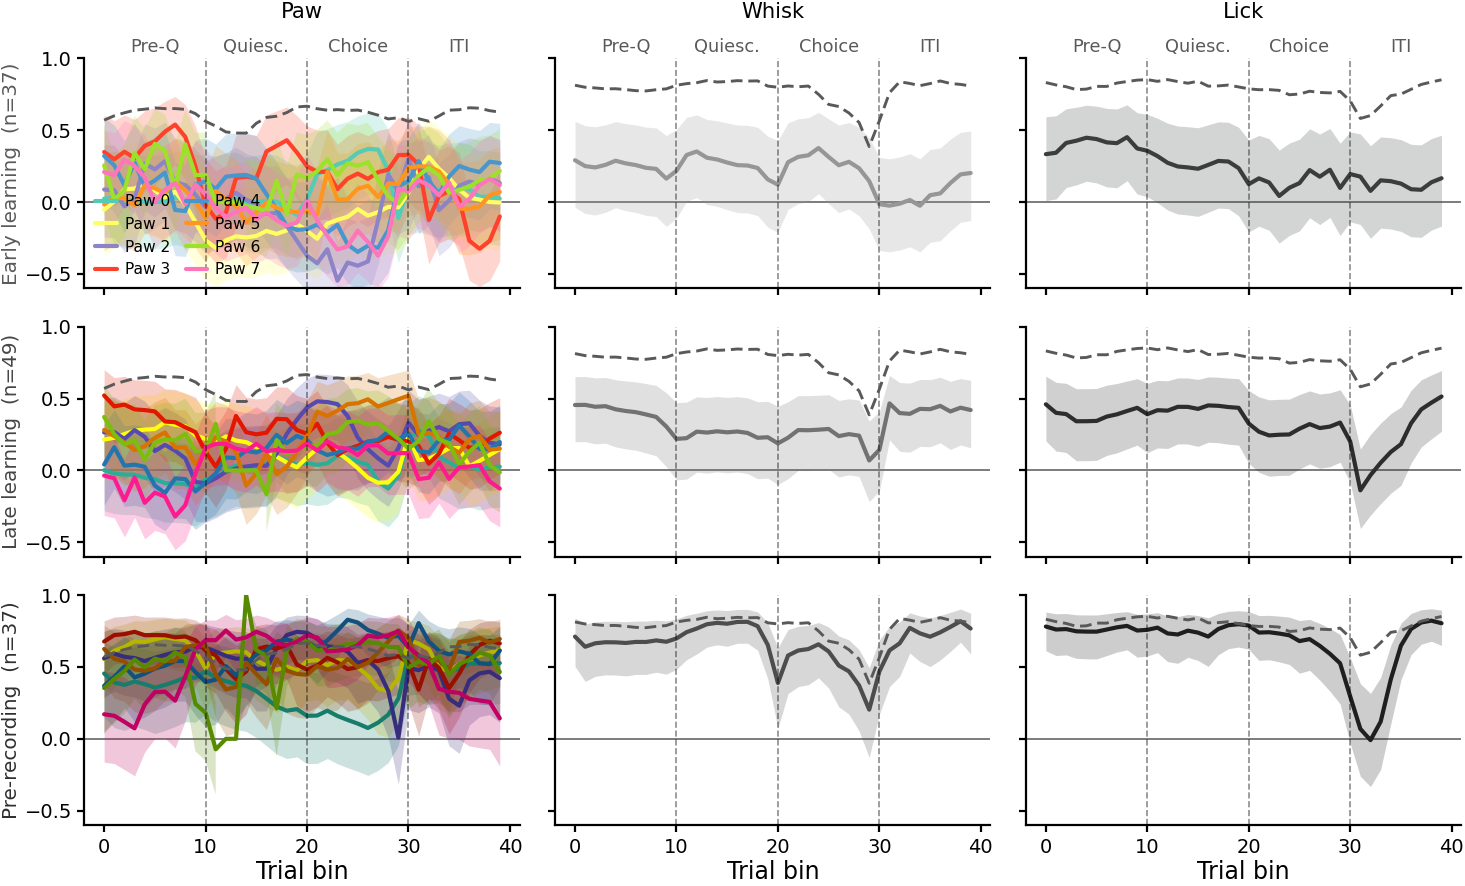

In [7]:
"""
ONE PANEL PER TIMEPOINT -- the layout where the error bands are readable
=======================================================================
Same numbers as the overlay above, but the timepoints are no longer stacked on
one another, so their Fisher 95% bands stop overlapping. The colour convention is
unchanged: hue = syllable (Set3, from paper_style), intensity = closeness to the
proficient state.

by='modality'  columns are Paw / Whisk / Lick, rows are timepoints
by='feature'   one panel per syllable -- a single line and a single band per
               panel, which is the layout to use when the bands are the point

With more than 4 groups the grid transposes itself (syllables down the rows,
timepoints across the columns) so the figure stays a sensible shape; pass
transpose=True/False to force it.

`w`/`h` are the panel size as a fraction of a paper_style 'single' panel, and the
grids are small-multiples, so they sit well below 1.
"""
def plot_correlation_grid(tps=None, features=None, by='modality', transpose='auto',
                          show_ceiling=True, show_ci=True, ci_alpha=0.22,
                          ylim=(-0.6, 1.0), w=0.72, h=0.62, save=None):
    ps.reapply()
    tps = list(TPS if tps is None else tps)
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']

    if by == 'modality':
        groups = [(mod, [j for j in feats
                         if features is None or FEATURE_NAMES[j] in features])
                  for mod, feats in MODALITIES.items()]
        groups = [g for g in groups if g[1]]
    elif by == 'feature':
        names = FEATURE_NAMES if features is None else list(features)
        groups = [(nm, [FEATURE_NAMES.index(nm)]) for nm in names]
    else:
        raise ValueError("by must be 'modality' or 'feature'")

    transpose = (len(groups) > 4) if transpose == 'auto' else bool(transpose)
    nrow, ncol = (len(groups), len(tps)) if transpose else (len(tps), len(groups))
    fig, axes = panels(nrow, ncol, w=w, h=h, sharex=True, sharey=True, squeeze=False)

    for ti, tp in enumerate(tps):
        wt = tp_weight(tp, tps)
        for gi, (gname, feats) in enumerate(groups):
            ax = axes[gi][ti] if transpose else axes[ti][gi]
            for j in feats:
                col = shade(FEATURE_COLORS[j], wt)
                ax.plot(bins, CORR[tp]['r'][:, j], color=col, lw=lw,
                        label=FEATURE_NAMES[j] if (ti == 0 and len(feats) > 1) else None)
                if show_ci:
                    ax.fill_between(bins, CORR[tp]['lo'][:, j], CORR[tp]['hi'][:, j],
                                    color=col, alpha=ci_alpha, lw=0)
            if show_ceiling:
                ax.plot(bins, np.nanmean(CEIL['r'][:, feats], axis=1), color='0.35',
                        ls=(0, (4, 2)), lw=lw * 0.7, zorder=5)
            first_row = (gi == 0) if transpose else (ti == 0)
            first_col = (ti == 0) if transpose else (gi == 0)
            _epoch_furniture(ax, label_epochs=first_row)
            if first_row:
                head = f"{TP_LABEL.get(tp, tp)}  (n={CORR[tp]['n']})" if transpose else gname
                panel_title(ax, head, above_epochs=True, fontsize=small(0.95),
                            color=shade('#6f6f6f', wt) if transpose else 'k')
            if first_col:
                side = gname if transpose else f"{TP_LABEL.get(tp, tp)}  (n={CORR[tp]['n']})"
                ax.set_ylabel(side, fontsize=small(0.9),
                              color='k' if transpose else shade('#6f6f6f', wt))
            ax.set_ylim(*ylim)
    for ax in axes[-1]:
        ax.set_xlabel('Trial bin')
    if by == 'modality':
        axes[0][0].legend(fontsize=small(0.7), ncol=2, loc='lower left')
    note(fig, f'correlation across mice vs {REF} ({METHOD}) -- one panel per timepoint\n'
              f'band = Fisher 95% CI on r, dashed = within-{REF} split-half ceiling')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


# rows = timepoints, columns = Paw / Whisk / Lick
fig_grid_mod = plot_correlation_grid(by='modality', save='sylcorr_grid_modality')

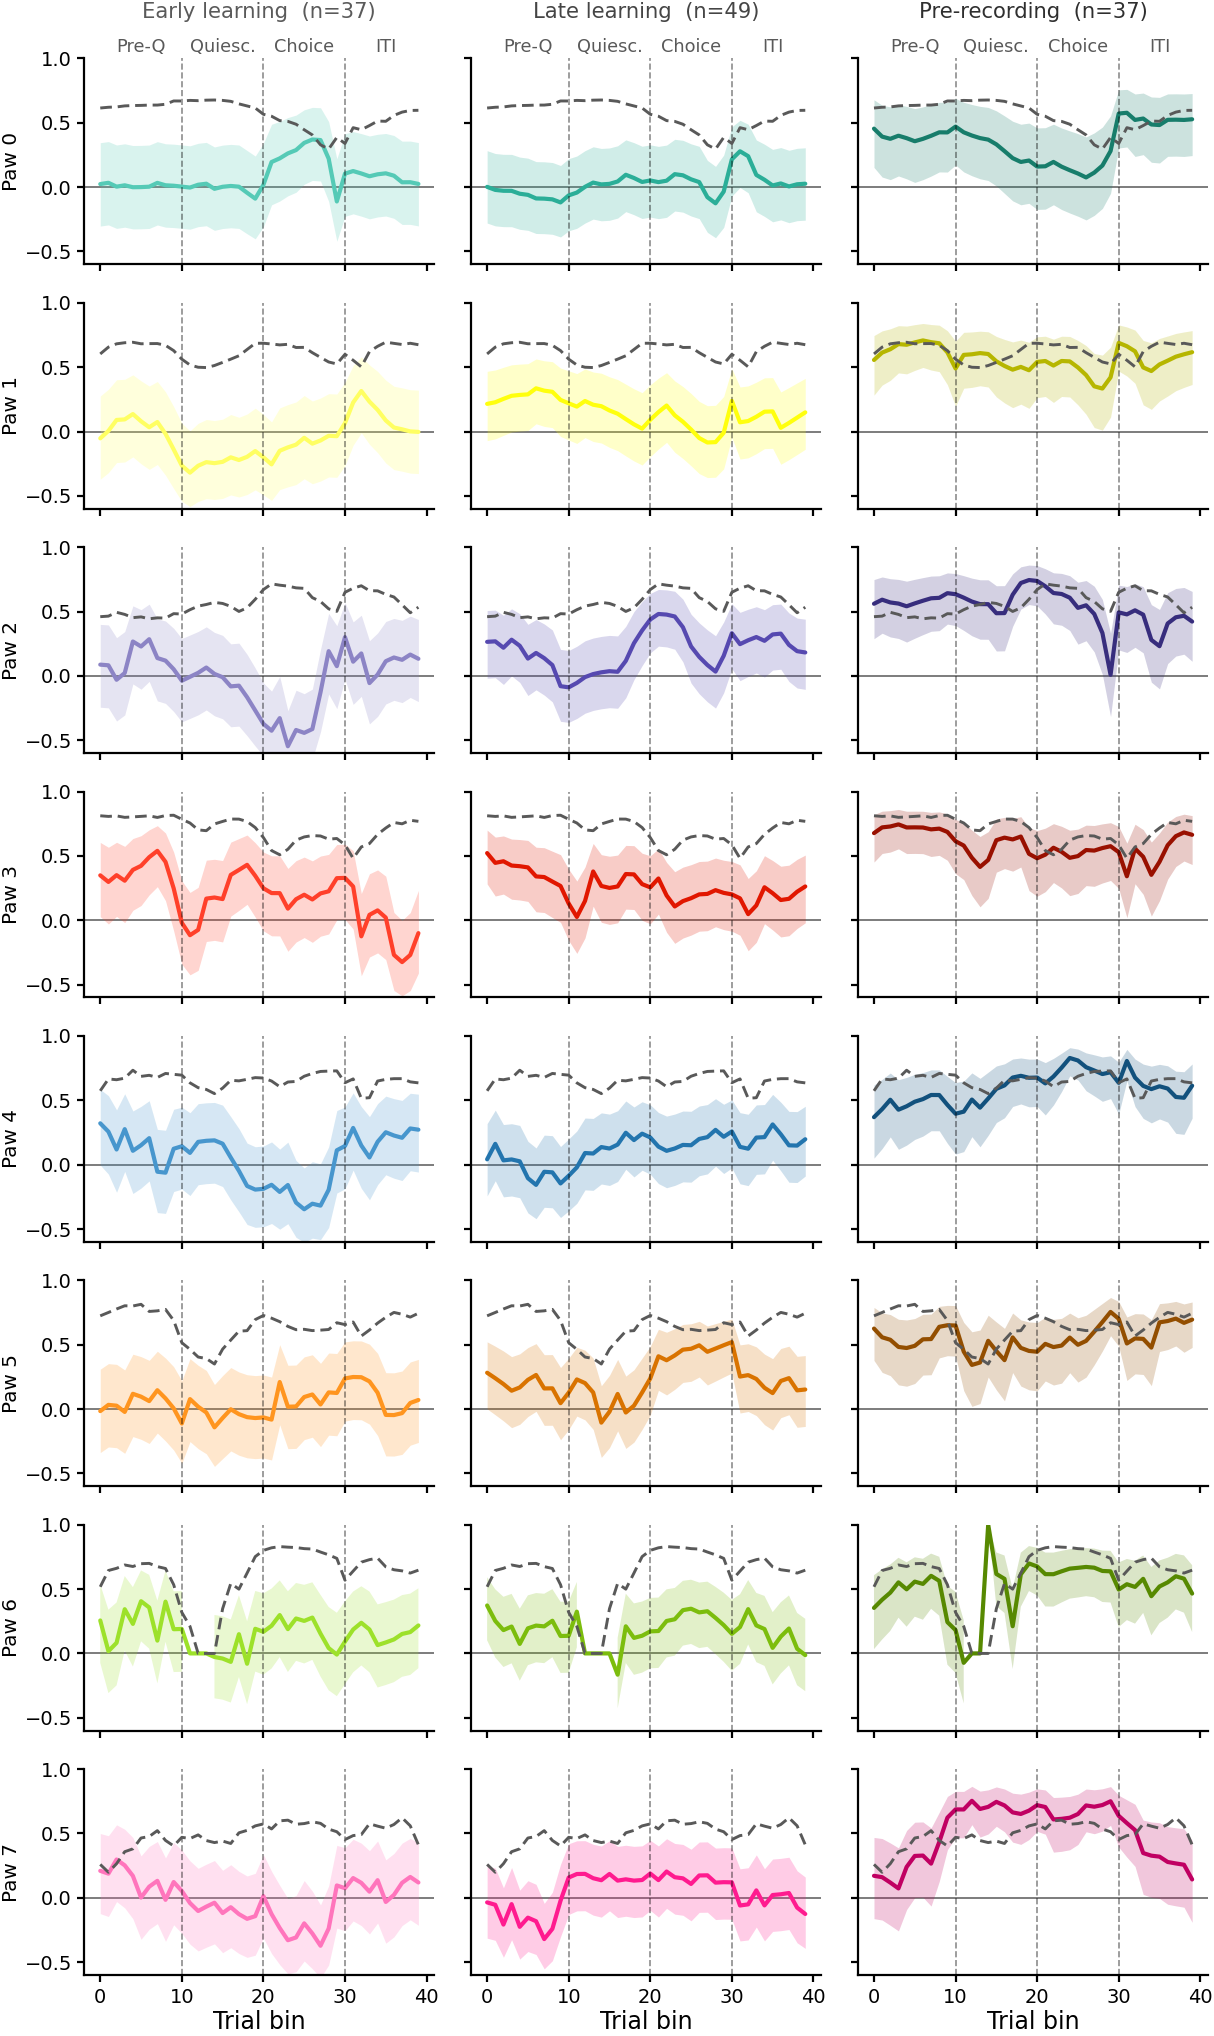

In [8]:
""" one panel per syllable per timepoint: a single band per panel, nothing hidden.
    Small multiples, so the panels are ~0.6 of a paper_style single panel. """
fig_grid_paw = plot_correlation_grid(
    by='feature', features=[f'Paw {i}' for i in range(N_PAW_STATES)],
    w=0.6, h=0.52)

wrote figures/sylcorr_grid_whisk_lick_poster_14-09-2026.png, figures/sylcorr_grid_whisk_lick_poster_14-09-2026.svg


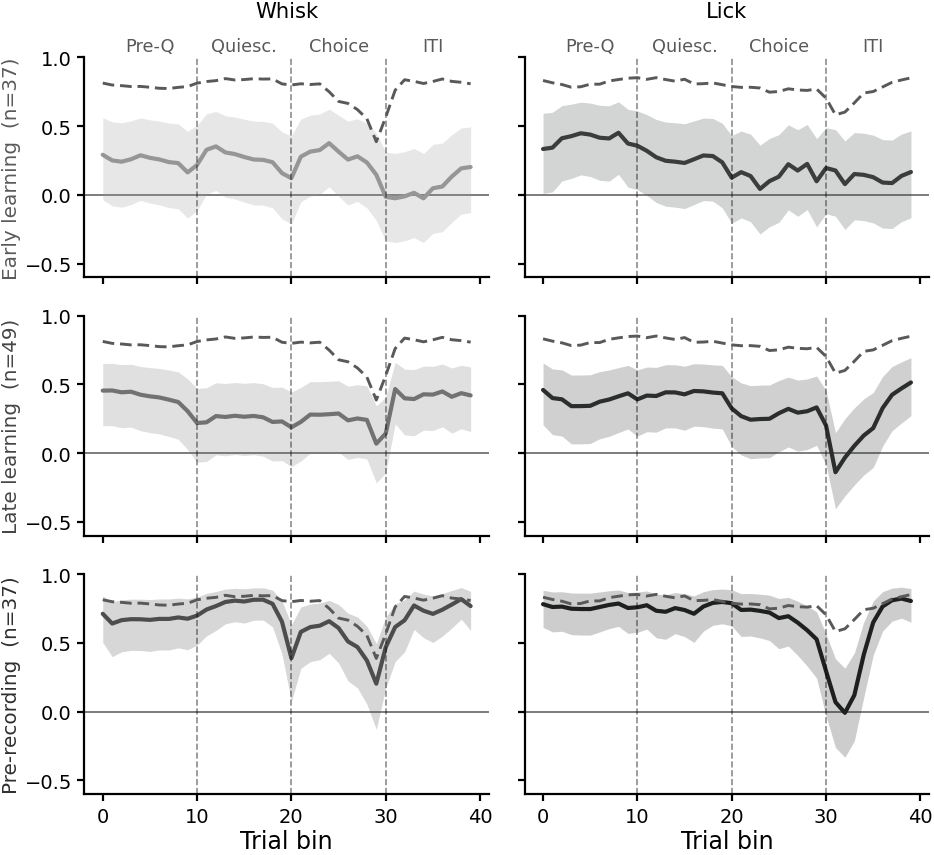

In [9]:
fig_grid_wl = plot_correlation_grid(by='feature', features=['Whisk', 'Lick'],
                                    transpose=False, w=0.7, h=0.6,
                                    save='sylcorr_grid_whisk_lick')

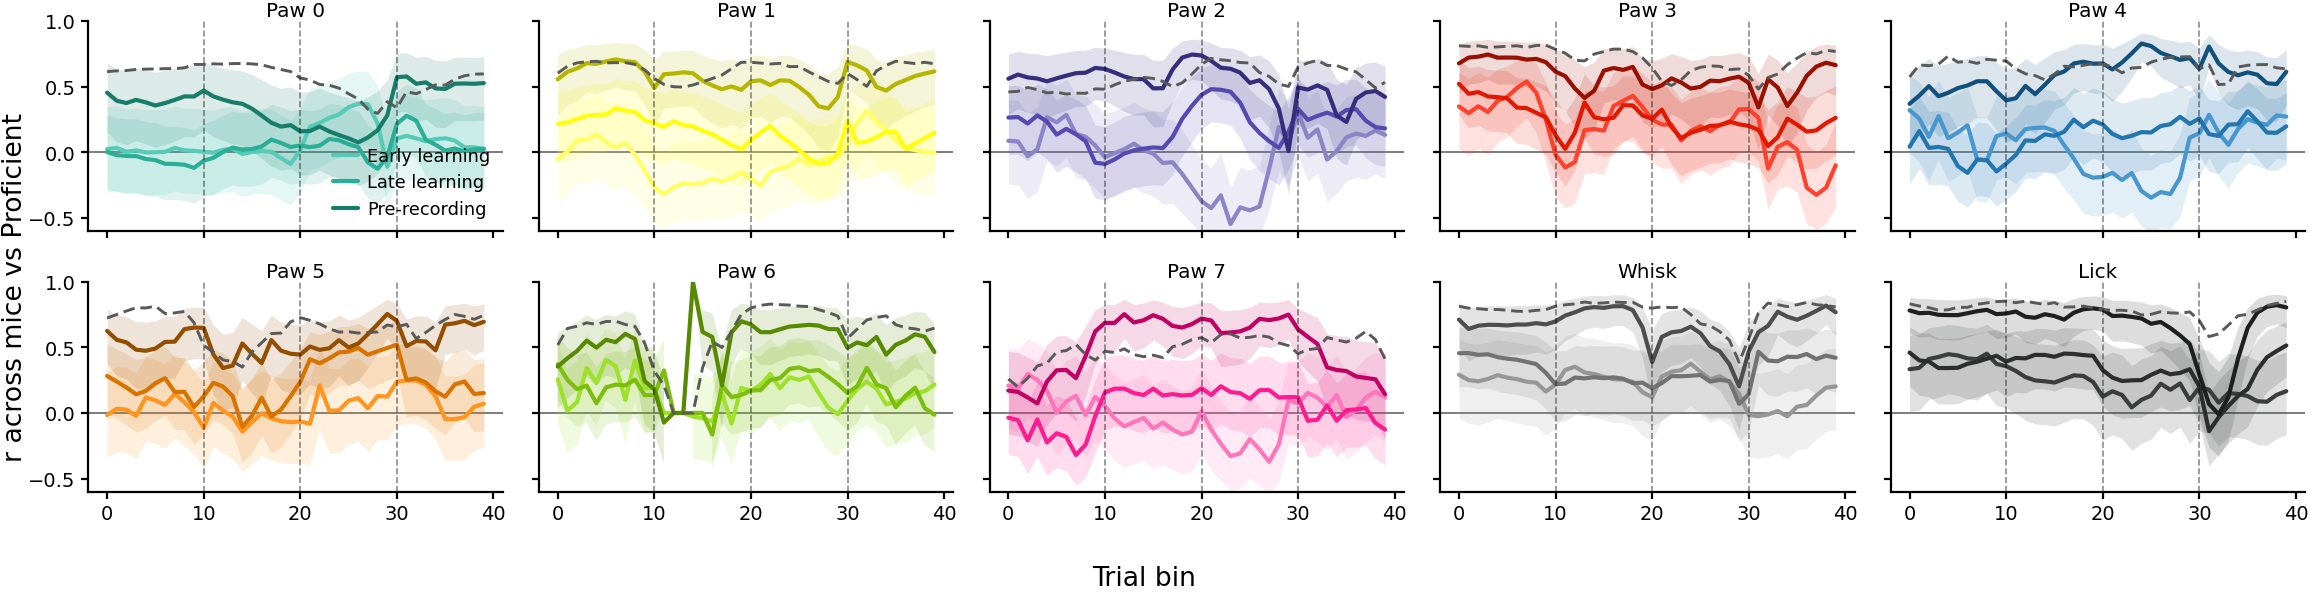

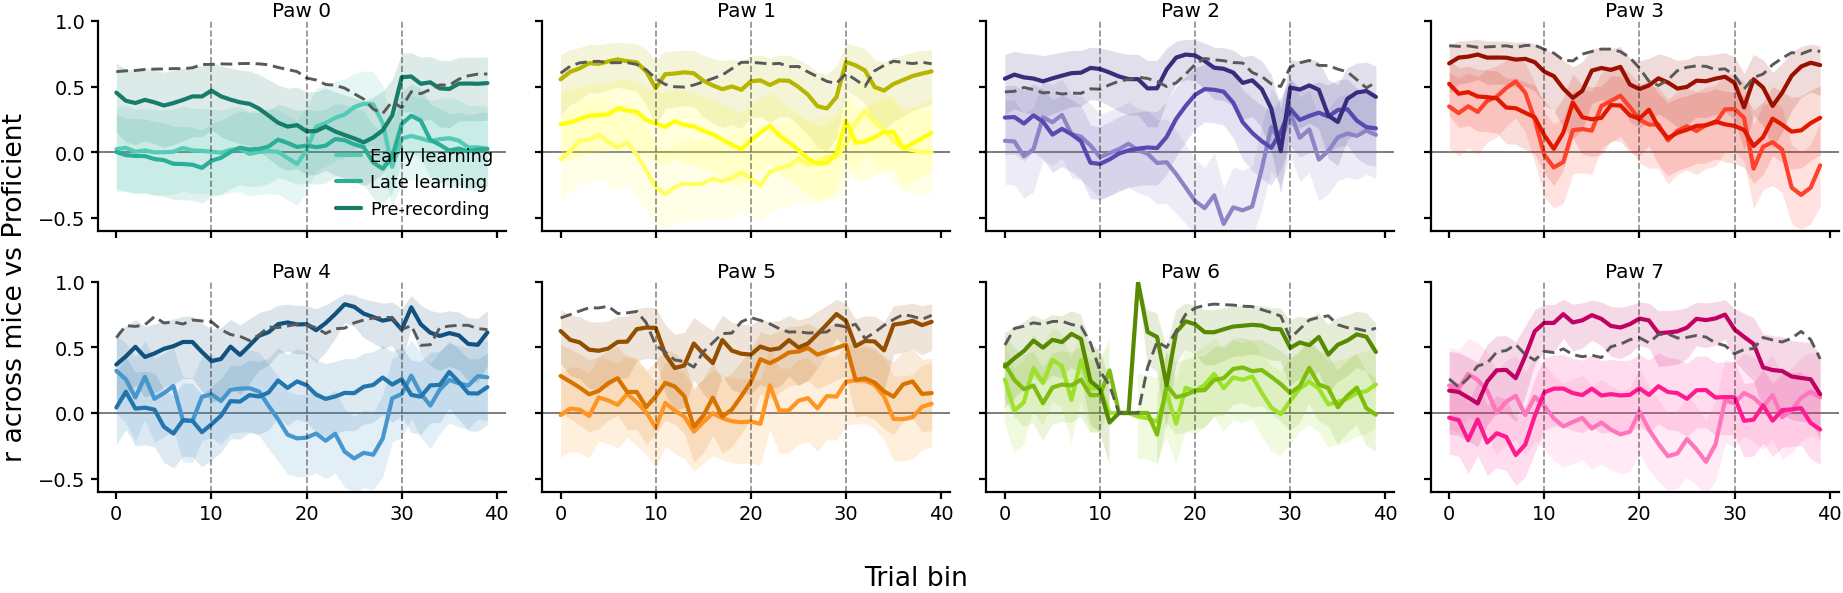

In [10]:
""" Paw states are crowded together above; this splits them out one panel per
    syllable, with the same intensity-by-distance convention. """
def plot_correlation_by_feature(tps=None, features=None, ncol=5, show_ceiling=True,
                                show_ci=True, ylim=(-0.6, 1.0), w=0.68, h=0.62,
                                save=None):
    ps.reapply()
    tps = list(TPS if tps is None else tps)
    features = FEATURE_NAMES if features is None else features
    idx = [FEATURE_NAMES.index(f) for f in features]
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']
    nrow = int(np.ceil(len(idx) / ncol))
    fig, axes = panels(nrow, ncol, w=w, h=h, sharex=True, sharey=True, squeeze=False)
    for k, j in enumerate(idx):
        ax = axes[k // ncol][k % ncol]
        for tp in tps:
            col = shade(FEATURE_COLORS[j], tp_weight(tp, tps))
            ax.plot(bins, CORR[tp]['r'][:, j], color=col, lw=lw,
                    label=TP_LABEL.get(tp, tp))
            if show_ci:
                ax.fill_between(bins, CORR[tp]['lo'][:, j], CORR[tp]['hi'][:, j],
                                color=col, alpha=0.15, lw=0)
        if show_ceiling:
            ax.plot(bins, CEIL['r'][:, j], color='0.35', ls=(0, (4, 2)), lw=lw * 0.7)
        _epoch_furniture(ax)
        ax.set_title(FEATURE_NAMES[j], fontsize=small(0.9))
        ax.set_ylim(*ylim)
    for k in range(len(idx), nrow * ncol):
        axes[k // ncol][k % ncol].set_axis_off()
    axes[0][0].legend(fontsize=small(0.8))
    fig.supxlabel('Trial bin'); fig.supylabel(f'r across mice vs {REF}')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_features = plot_correlation_by_feature()

#%%
""" paw states only, one panel each -- the uncluttered version of the paw panel """
fig_paws = plot_correlation_by_feature(
    features=[f'Paw {i}' for i in range(N_PAW_STATES)], ncol=4)

wrote figures/sylcorr_maps_poster_14-09-2026.png, figures/sylcorr_maps_poster_14-09-2026.svg


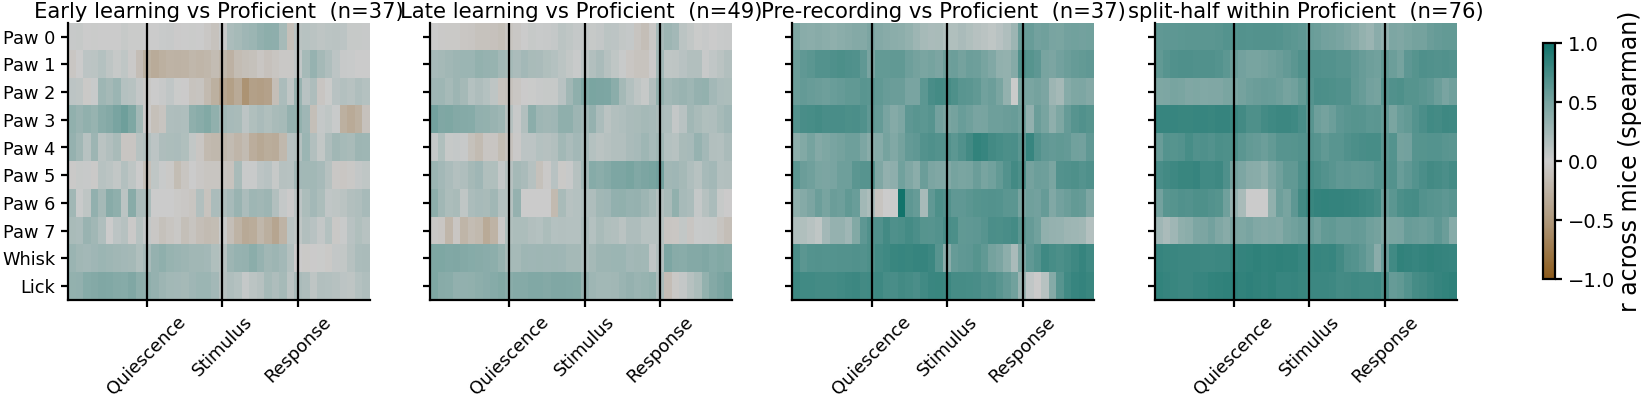

In [11]:
""" The same numbers as a map: syllable x trial bin, one panel per timepoint.
    Useful for spotting whether the stable moments are the same ones for every
    syllable (vertical stripes) or syllable-specific (horizontal stripes). """
# THE COLORMAP IS ps.CORR_CMAP, the paper's correlation map, so every correlation
# map in the paper reads the same way. Why it is brown <-> teal rather than a
# built-in diverging map:
#   * blue-red is spoken for -- ps.LD1_CMAP is coolwarm -- so a red/blue map here
#     would read as an LD1 map;
#   * PuOr_r and PiYG collide with the timepoint ramp (ps.TIMEPOINT), which now runs
#     coral -> deep purple: an orange or purple cell here would read as a timepoint;
#   * it is GREY AT ZERO, not white, so a near-zero cell stays visible as "nothing
#     found" instead of dissolving into the page -- and white is left free to mean
#     "not estimated" (cmap.set_bad).
# With FLAT_AS_ZERO the flat cells READ as zero, so the map has no gaps and the epoch
# averages include them.
CORR_CMAP = ps.CORR_CMAP


def plot_correlation_heatmaps(tps=None, vmax=None, include_ceiling=True,
                              w=0.8, h=0.72, save=None):
    ps.reapply()
    tps = list(TPS if tps is None else tps)
    panels_ = [(tp, CORR[tp]['r'], CORR[tp].get('flat'),
                f"{TP_LABEL.get(tp, tp)} vs {REF}  (n={CORR[tp]['n']})") for tp in tps]
    if include_ceiling:
        panels_.append(('ceiling', CEIL['r'], CEIL.get('flat'),
                        f"split-half within {REF}  (n={CEIL['n']})"))
    if vmax is None:
        vmax = float(np.nanmax([np.nanmax(np.abs(p[1])) for p in panels_]))
    fig, axes = panels(1, len(panels_), w=w, h=h, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (_, R, F, ttl) in zip(axes, panels_):
        # ps.corr_norm keeps zero at the colormap's grey centre whatever vmax is
        im = ax.imshow(R.T, aspect='auto', cmap=ps.CORR_CMAP,
                       norm=ps.corr_norm(vmax), interpolation='nearest')
        if F is not None and F.any():
            yy, xx = np.where(F.T)      # imshow shows R.T, so features are the rows
            # ax.scatter(xx, yy, s=plt.rcParams['lines.markersize'], marker='x',
            #            color='0.2', linewidths=0.7)
        for e in EPOCH_EDGES:
            ax.axvline(e, color='k', lw=plt.rcParams['axes.linewidth'])
        ax.set_yticks(range(len(FEATURE_NAMES)))
        ax.set_yticklabels(FEATURE_NAMES, fontsize=small(0.8))
        ax.set_title(ttl, fontsize=small(0.95))
        ax.set_xticks(EPOCH_EDGES, ['Quiescence', 'Stimulus', 'Response'],
                      fontsize=small(0.8), rotation=45)
    fig.colorbar(im, ax=axes.tolist(), label=f'r across mice ({METHOD})', shrink=0.85)
    note(fig, 'x = no variance across mice at that cell (r reported as 0, not estimated)')
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_maps = plot_correlation_heatmaps(save='sylcorr_maps')

In [12]:
"""
WHERE IN THE TRIAL IS INDIVIDUALITY MOST STABLE?
Collapses each map to one number per (epoch, modality, timepoint), which is the
version that goes in a table rather than a figure.
"""
epoch_of_bin = np.digitize(np.arange(N_BINS), EPOCH_EDGES)
rows = []
for tp in TPS:
    for mod, feats in MODALITIES.items():
        for e, nm in enumerate(EPOCH_NAMES):
            sel = epoch_of_bin == e
            rows.append(dict(timepoint=tp, modality=mod, epoch=nm,
                             r=np.nanmean(CORR[tp]['r'][np.ix_(sel, feats)]),
                             ceiling=np.nanmean(CEIL['r'][np.ix_(sel, feats)]),
                             n_mice=CORR[tp]['n']))
summary = pd.DataFrame(rows)
summary['r_over_ceiling'] = summary['r'] / summary['ceiling']
print(summary.pivot_table(index=['modality', 'epoch'], columns='timepoint',
                          values='r', sort=False).round(3).to_string())
print("\nas a fraction of the split-half ceiling")
print(summary.pivot_table(index=['modality', 'epoch'], columns='timepoint',
                          values='r_over_ceiling', sort=False).round(2).to_string())
summary


timepoint                Early   Late  Pre-rec
modality epoch                                
Paw      Pre-quiescence  0.142  0.126    0.516
         Quiescence     -0.019  0.115    0.516
         Choice         -0.016  0.198    0.537
         ITI             0.104  0.154    0.525
Whisk    Pre-quiescence  0.249  0.412    0.674
         Quiescence      0.269  0.251    0.768
         Choice          0.265  0.235    0.503
         ITI             0.058  0.398    0.707
Lick     Pre-quiescence  0.405  0.390    0.762
         Quiescence      0.274  0.432    0.755
         Choice          0.143  0.289    0.686
         ITI             0.136  0.214    0.474

as a fraction of the split-half ceiling
timepoint                Early  Late  Pre-rec
modality epoch                               
Paw      Pre-quiescence   0.23  0.20     0.82
         Quiescence      -0.03  0.21     0.93
         Choice          -0.03  0.32     0.86
         ITI              0.17  0.25     0.85
Whisk    Pre-quiescence  

,timepoint,modality,epoch,r,ceiling,n_mice,r_over_ceiling
0,Early,Paw,Pre-quiescence,0.141727,0.629698,37,0.225072
1,Early,Paw,Quiescence,-0.018602,0.556045,37,-0.033455
2,Early,Paw,Choice,-0.016038,0.627596,37,-0.025554
3,Early,Paw,ITI,0.104385,0.615908,37,0.169481
4,Early,Whisk,Pre-quiescence,0.249115,0.788652,37,0.315874
5,Early,Whisk,Quiescence,0.268683,0.832786,37,0.322632
6,Early,Whisk,Choice,0.264987,0.687430,37,0.385475
7,Early,Whisk,ITI,0.057641,0.792209,37,0.072760
8,Early,Lick,Pre-quiescence,0.405422,0.814700,37,0.497633
9,Early,Lick,Quiescence,0.273716,0.828473,37,0.330386


variance components at Proficient: 76 mice, 4.0 sessions each on average
wrote figures/sylcorr_boundary_diagnostic_poster_14-09-2026.png, figures/sylcorr_boundary_diagnostic_poster_14-09-2026.svg


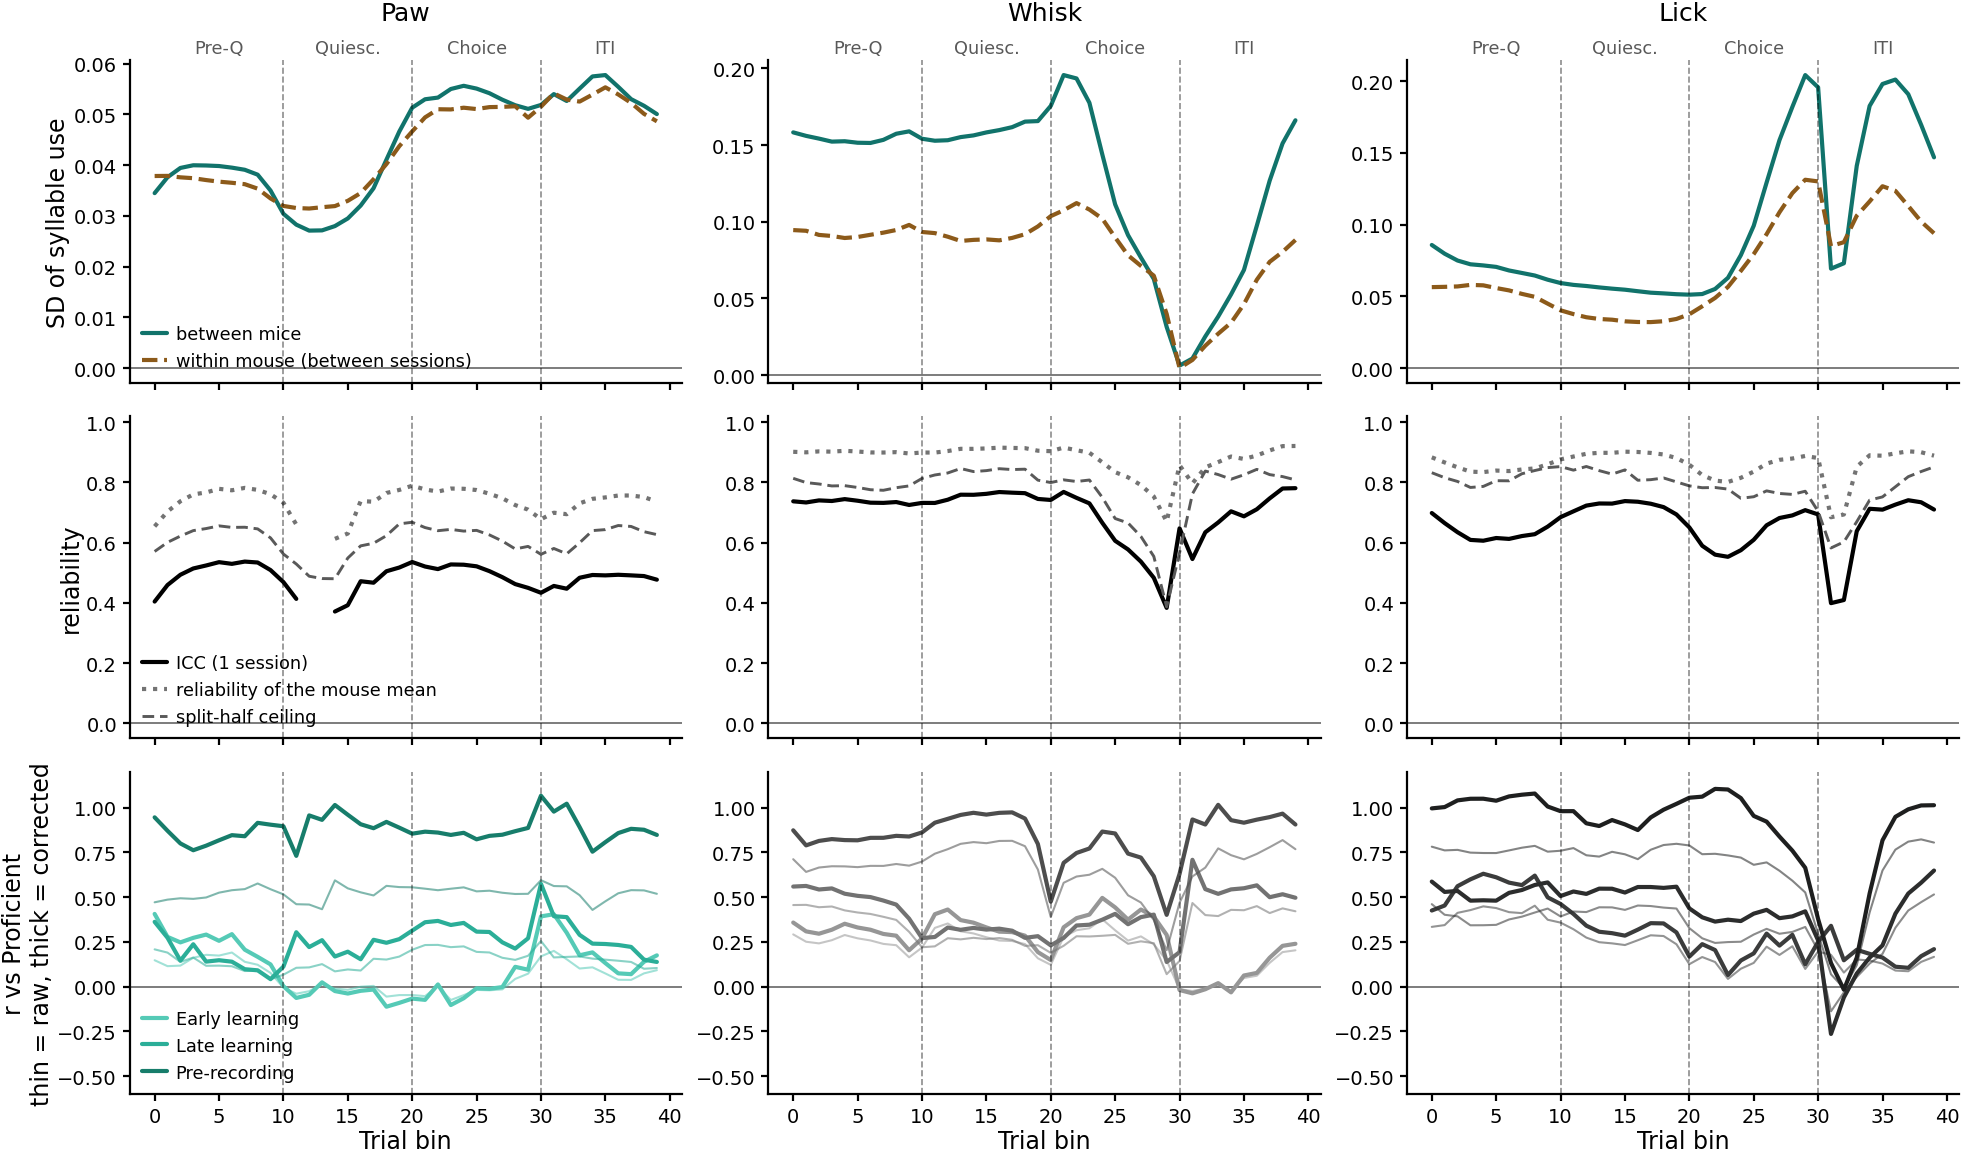


             between SD    within SD      ICC
boundary         0.0574       0.0485    0.523
interior         0.0584       0.0499    0.522
between falls at the boundary -> stereotypy;  within rises -> binning noise;
both -> the dip says nothing about individuality either way.


In [13]:
"""
WHY THE CORRELATION DIPS AT THE EPOCH BOUNDARIES
================================================
The 10 bins of an epoch are DECILES of that epoch (rescale_sequence -> np.array_split
-> mode, in segmentation_functions.py), so the boundaries themselves are aligned
exactly. The dip therefore has to come from the variance, and there are two ways to
lose a correlation, which this cell separates:

  BETWEEN-MOUSE variance falls   the task pins every mouse to the same behaviour at
                                 the event (stereotypy) -- there is no individuality
                                 there to detect, and r -> 0 even with perfect data
  WITHIN-MOUSE variance rises    a bin straddling a behavioural transition is a
                                 near-tie, so mode() flips the whole bin's label on a
                                 one-frame difference; event-time error also bites
                                 hardest where the profile is steep

Both push the correlation down, and only these two curves say which is happening.
Within-mouse variance needs several sessions per mouse, so it is estimated on the
proficient sessions (and Pre-rec if you ask for it), not on Early/Late.
"""
def variance_components(label=REF, min_sessions=2):
    """Per (bin, feature): between-mouse variance, within-mouse (between-session)
    variance, and the resulting ICC = reliability of ONE session.

    The variance of a mouse's mean is not the between-mouse variance: it still carries
    within/n_sessions, so that term is subtracted before the ratio is taken."""
    sel = timepoint == label
    idx = {m: np.where(sel & (mice == m))[0] for m in np.unique(mice[sel])}
    idx = {m: i for m, i in idx.items() if len(i) >= min_sessions}
    assert len(idx) >= 3, f"only {len(idx)} mice have >= {min_sessions} {label} sessions"
    n_i = np.array([len(i) for i in idx.values()], float)
    means = np.stack([recon[i].mean(0) for i in idx.values()])
    within = np.stack([recon[i].var(0, ddof=1) for i in idx.values()]).mean(0)
    between = np.maximum(means.var(0, ddof=1) - within * np.mean(1.0 / n_i), 0.0)
    with np.errstate(invalid='ignore', divide='ignore'):
        icc = between / (between + within)                       # one session
        rel_mean = between / (between + within / (len(n_i) / np.sum(1.0 / n_i)))
    print(f"variance components at {label}: {len(idx)} mice, "
          f"{n_i.mean():.1f} sessions each on average")
    return dict(between=between, within=within, icc=icc, rel_mean=rel_mean,
                n_mice=len(idx), n_sessions=n_i)


VC = variance_components(REF)

# Attenuation correction. r is bounded by the reliability of BOTH sides:
#   r_true ~ r / sqrt(rel_proficient * rel_earlier)
# The proficient side is measured (rel_mean, a multi-session average). The earlier
# timepoints have one session per mouse, so their reliability is not estimable there
# and the single-session ICC measured at proficient is used as a stand-in -- an
# assumption, not a measurement, so read the corrected curves as an upper bound.
MIN_REL = 0.05


def attenuation_corrected(tp, vc=VC):
    denom = np.sqrt(np.clip(vc['rel_mean'], MIN_REL, 1) * np.clip(vc['icc'], MIN_REL, 1))
    out = CORR[tp]['r'] / denom
    out[(vc['icc'] < MIN_REL) | ~np.isfinite(out)] = np.nan
    return np.clip(out, -1.5, 1.5)


def plot_boundary_diagnostic(tps=None, vc=VC, ylim_r=(-0.6, 1.2), w=0.95, h=0.8,
                             save=None):
    ps.reapply()
    tps = list(TPS if tps is None else tps)
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']
    fig, axes = panels(3, len(MODALITIES), w=w, h=h, sharex=True, squeeze=False)
    for c_i, (mod, feats) in enumerate(MODALITIES.items()):
        # row 1 -- the two variances (as SDs, which are on the same scale as the data)
        ax = axes[0][c_i]
        ax.plot(bins, np.sqrt(vc['between'][:, feats]).mean(1),
                color=VAR_COLOR['between'], lw=lw, label='between mice')
        ax.plot(bins, np.sqrt(vc['within'][:, feats]).mean(1),
                color=VAR_COLOR['within'], lw=lw, ls='--',
                label='within mouse (between sessions)')
        panel_title(ax, mod, above_epochs=True)
        if c_i == 0:
            ax.set_ylabel('SD of syllable use'); ax.legend(fontsize=small(0.8))

        # row 2 -- what that does to the reliability of individual differences
        ax = axes[1][c_i]
        ax.plot(bins, vc['icc'][:, feats].mean(1), color='k', lw=lw,
                label='ICC (1 session)')
        ax.plot(bins, vc['rel_mean'][:, feats].mean(1), color='0.45', lw=lw, ls=':',
                label='reliability of the mouse mean')
        ax.plot(bins, np.nanmean(CEIL['r'][:, feats], axis=1), color='0.35',
                ls=(0, (4, 2)), lw=lw * 0.7, label='split-half ceiling')
        ax.set_ylim(-0.05, 1.02)
        if c_i == 0:
            ax.set_ylabel('reliability'); ax.legend(fontsize=small(0.8))

        # row 3 -- r before and after dividing out the unreliability
        ax = axes[2][c_i]
        for tp in tps:
            col = shade(FEATURE_COLORS[feats[0]], tp_weight(tp, tps))
            ax.plot(bins, CORR[tp]['r'][:, feats].mean(1), color=col, lw=lw * 0.5,
                    alpha=0.55)
            ax.plot(bins, np.nanmean(attenuation_corrected(tp)[:, feats], axis=1),
                    color=col, lw=lw, label=TP_LABEL.get(tp, tp))
        ax.set_ylim(*ylim_r); ax.set_xlabel('Trial bin')
        if c_i == 0:
            ax.set_ylabel(f'r vs {REF}\nthin = raw, thick = corrected')
            ax.legend(fontsize=small(0.8))
    for row in axes:
        for ax in row:
            _epoch_furniture(ax, label_epochs=(ax in list(axes[0])))
    note(fig, 'is the boundary dip stereotypy (between-mouse variance falls) or '
              'binning noise (within-mouse variance rises)?')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_diag = plot_boundary_diagnostic(save='sylcorr_boundary_diagnostic')

# the same comparison as numbers: bins next to an epoch edge vs the rest
edge = np.zeros(N_BINS, bool)
for e in EPOCH_EDGES:
    edge[[e - 1, e]] = True
print(f"\n{'':10s} {'between SD':>12s} {'within SD':>12s} {'ICC':>8s}")
for nm, sel_b in [('boundary', edge), ('interior', ~edge)]:
    print(f"{nm:10s} {np.sqrt(VC['between'][sel_b]).mean():12.4f} "
          f"{np.sqrt(VC['within'][sel_b]).mean():12.4f} "
          f"{np.nanmean(VC['icc'][sel_b]):8.3f}")
print("between falls at the boundary -> stereotypy;  within rises -> binning noise;\n"
      "both -> the dip says nothing about individuality either way.")

learning speed file: /home/ines/repositories/representation_learning_variability/learning_prediction/training_time_05-05-2026
101 mice with a learning-speed value; 99 of them are in the Proficient set

per-mouse score vs log(training_days), Spearman  [Proficient = reference]
timepoint   score                rho         p     n
Early       maturity          -0.166    0.3247    37  
Early       stability         -0.037    0.8261    37  
Early       identifiability   -0.008    0.9616    37  
Late        maturity          -0.085    0.5663    48  
Late        stability          0.253    0.0832    48  
Late        identifiability    0.145    0.3254    48  
Pre-rec     maturity          -0.335    0.0491    35 *
Pre-rec     stability         -0.180    0.3006    35  
Pre-rec     identifiability   -0.297    0.0836    35  
Early is the only timepoint not defined by when the mouse finished learning.
wrote figures/sylcorr_maturity_vs_learning_poster_14-09-2026.png, figures/sylcorr_maturity_vs_learn

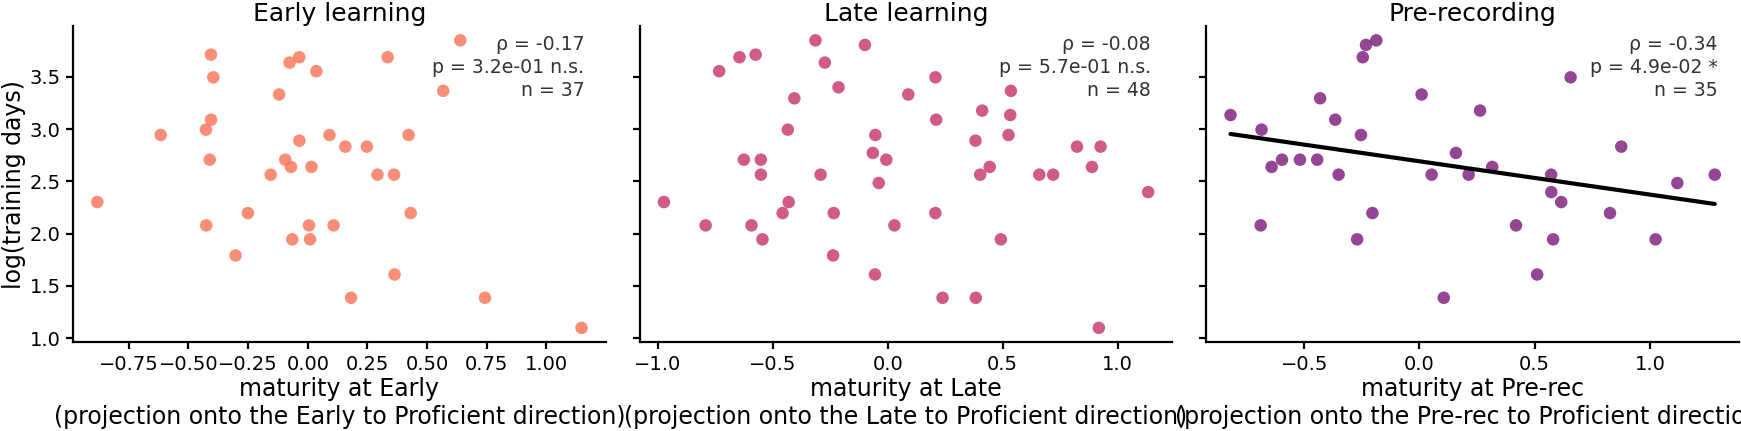

In [14]:
"""
WHICH MICE ALREADY BEHAVE LIKE PROFICIENT MICE, AND DOES IT PREDICT LEARNING SPEED?
==================================================================================
Three per-mouse scores, all computed on the same (bin x syllable) profiles, each
answering a different question:

  MATURITY      how far along the population's own learning direction the mouse
                already is at that timepoint. The direction is d = mean(Proficient)
                - mean(T); the score is the mouse's deviation projected onto it.
                "Its behaviour is already proficient-like."
  STABILITY     the correlation between the mouse's DEVIATION profile at T and its
                own deviation profile when proficient. "Its individual signature is
                already the one it will end up with." (Deviations, not raw profiles:
                raw profiles all correlate at ~0.95 because the task-locked structure
                is shared, which would drown the individual part.)
  IDENTIFIABLE  rank its own proficient profile among all proficient mice, by
                similarity to its profile at T. 1 = "recognisable as itself".

All three use leave-one-out means, so a mouse never contributes to the reference it
is being scored against.

CAVEAT worth deciding on before reading the learning-speed correlations: Late is the
LAST TRAINING SESSION and Pre-rec is defined relative to recording, so WHEN they
happen already depends on how fast the mouse learned. Early is session 1 -- the only
timepoint whose definition is independent of learning speed, and so the clean test.
"""
from scipy.stats import spearmanr, pearsonr


def _flat(P, features=None, epochs=None):
    """(n_mice, n_bins, n_feat) -> (n_mice, n_selected_cells)."""
    fj = (list(range(len(FEATURE_NAMES))) if features is None
          else [FEATURE_NAMES.index(f) for f in features])
    if epochs is None:
        bi = list(range(N_BINS))
    else:
        eb = np.digitize(np.arange(N_BINS), EPOCH_EDGES)
        bi = [b for b in range(N_BINS) if EPOCH_NAMES[eb[b]] in epochs]
    return P[:, bi][:, :, fj].reshape(len(P), -1)


def _loo_mean(A, k):
    return (A.sum(0) - A[k]) / (len(A) - 1)


def maturity_score(label, ref=REF, features=None, epochs=None):
    ms_t, A = PROFILES[label]; ms_r, B = PROFILES[ref]
    A = _flat(A, features, epochs); B = _flat(B, features, epochs)
    ref_pos = {m: j for j, m in enumerate(ms_r)}
    out = {}
    for k, m in enumerate(ms_t):
        mu_t = _loo_mean(A, k)
        mu_r = _loo_mean(B, ref_pos[m]) if m in ref_pos else B.mean(0)
        d = mu_r - mu_t
        nrm = np.linalg.norm(d)
        out[m] = float((A[k] - mu_t) @ d / nrm) if nrm > 0 else np.nan
    return pd.Series(out, name='maturity')


def signature_stability(label, ref=REF, features=None, epochs=None, method=METHOD):
    ms_t, A = PROFILES[label]; ms_r, B = PROFILES[ref]
    shared = np.intersect1d(ms_t, ms_r)
    A = _flat(A, features, epochs); B = _flat(B, features, epochs)
    ia = pd.Index(ms_t).get_indexer(shared); ib = pd.Index(ms_r).get_indexer(shared)
    out = {}
    for m, ka, kb in zip(shared, ia, ib):
        a = A[ka] - _loo_mean(A, ka); b = B[kb] - _loo_mean(B, kb)
        ok = np.isfinite(a) & np.isfinite(b)
        f = spearmanr if method == 'spearman' else pearsonr
        out[m] = float(f(a[ok], b[ok])[0]) if ok.sum() > 3 else np.nan
    return pd.Series(out, name='stability')


def identifiability(label, ref=REF, features=None, epochs=None):
    """For each mouse: where its own proficient profile ranks among all proficient
    mice, ordered by similarity to its profile at `label`. 1 = best match."""
    ms_t, A = PROFILES[label]; ms_r, B = PROFILES[ref]
    shared = np.intersect1d(ms_t, ms_r)
    A = _flat(A, features, epochs); B = _flat(B, features, epochs)
    ia = pd.Index(ms_t).get_indexer(shared); ib = pd.Index(ms_r).get_indexer(shared)
    dA = np.stack([A[k] - _loo_mean(A, k) for k in ia])
    dB = np.stack([B[k] - _loo_mean(B, k) for k in ib])
    Az = (dA - dA.mean(1, keepdims=True)) / dA.std(1, keepdims=True)
    Bz = (dB - dB.mean(1, keepdims=True)) / dB.std(1, keepdims=True)
    C = Az @ Bz.T / Az.shape[1]                       # (n_shared, n_shared) correlations
    rank = 1 + (C > np.diag(C)[:, None]).sum(1)       # rank of the true match
    n = len(shared)
    return pd.DataFrame({'rank': rank, 'percentile': 1 - (rank - 1) / (n - 1),
                         'self_r': np.diag(C)}, index=shared)


""" LEARNING SPEED -- the file the rest of the paper uses, joined on mouse_name """
REPO = os.path.abspath(os.path.join(base_path, '..', '..'))
LEARNING_CANDIDATES = [
    os.path.join(REPO, 'learning_prediction', 'training_time_05-05-2026'),
    os.path.join(REPO, 'paper-individuality', 'learning_prediction', 'training_time_27-04-2026'),
]
LEARNING_FILE = next((p for p in LEARNING_CANDIDATES if os.path.exists(p)), None)
print('learning speed file:', LEARNING_FILE)
training = pd.read_parquet(LEARNING_FILE)
training['log_training'] = np.log(training['training_days'])
# same exclusion as 4_mice/LDA_behavior.ipynb: log_training of exactly 0 or 1
training = training.loc[~training['log_training'].isin([0, 1])].reset_index(drop=True)
LEARN = training.set_index('mouse_name')['log_training']
print(f"{len(LEARN)} mice with a learning-speed value; "
      f"{len(set(LEARN.index) & set(PROFILES[REF][0]))} of them are in the {REF} set")


def vs_learning(score, y=None):
    y = LEARN if y is None else y
    df = pd.concat([pd.Series(score, name='score'), y.rename('y')], axis=1).dropna()
    if len(df) < 6:
        return dict(rho=np.nan, p=np.nan, n=len(df), df=df)
    rho, p = spearmanr(df['score'], df['y'])
    return dict(rho=float(rho), p=float(p), n=len(df), df=df)


SCORES = {}
for tp in TPS:
    SCORES[tp] = pd.DataFrame({'maturity': maturity_score(tp),
                               'stability': signature_stability(tp)})
    SCORES[tp]['identifiability'] = identifiability(tp)['percentile']

print(f"\nper-mouse score vs log(training_days), Spearman  [{REF} = reference]")
print(f"{'timepoint':11s} {'score':16s} {'rho':>7s} {'p':>9s} {'n':>5s}")
for tp in TPS:
    for col in SCORES[tp].columns:
        r = vs_learning(SCORES[tp][col])
        star = '*' if r['p'] < 0.05 else ' '
        print(f"{tp:11s} {col:16s} {r['rho']:7.3f} {r['p']:9.4f} {r['n']:5d} {star}")
print("Early is the only timepoint not defined by when the mouse finished learning.")

ps.reapply()
fig, axes = panels(1, len(TPS), w=0.85, h=0.95, sharey=True)
axes = np.atleast_1d(axes)
for ax, tp in zip(axes, TPS):
    r = vs_learning(SCORES[tp]['maturity'])
    d = r['df']
    ax.scatter(d['score'], d['y'], s=plt.rcParams['lines.markersize'] ** 2,
               color=COLORS[tp], alpha=0.85, edgecolors='none')
    # THE CONVENTION (ps.regline): the fit is drawn ONLY where the correlation is
    # significant, because a line through a null result is read as a trend whatever
    # the caption says. The numbers sit inside the panel, so the title carries only
    # what the panel IS.
    ps.regline(ax, d['score'], d['y'], r['p'] < 0.05)
    annotate_rho(ax, r['rho'], r['p'], n=r['n'], loc='upper right')
    ax.set_title(TP_LABEL.get(tp, tp))
    ax.set_xlabel(f'maturity at {tp}\n(projection onto the {tp} to {REF} direction)')
axes[0].set_ylabel('log(training days)')
note(fig, 'are proficient-looking mice the fast learners?')
fig.tight_layout()
ps.savefig(fig, 'sylcorr_maturity_vs_learning', svg=True)
plt.show()

wrote figures/sylcorr_maturity_grid_poster_14-09-2026.png, figures/sylcorr_maturity_grid_poster_14-09-2026.svg


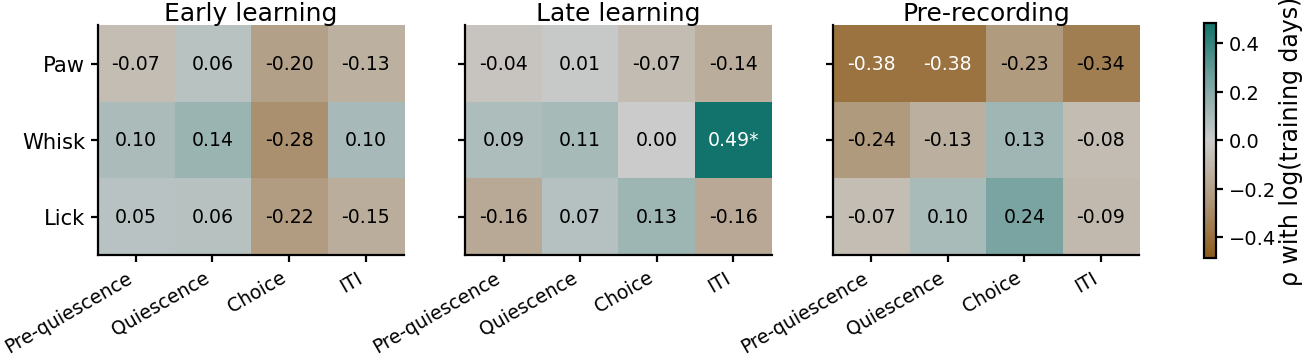

timepoint modality          epoch       rho        p  n        q
     Late    Whisk            ITI  0.485738 0.000466 48 0.016765
  Pre-rec      Paw     Quiescence -0.383747 0.022861 35 0.276288
  Pre-rec      Paw Pre-quiescence -0.383326 0.023024 35 0.276288
  Pre-rec      Paw            ITI -0.342200 0.044202 35 0.397820
    Early    Whisk         Choice -0.276271 0.097882 37 0.704753
  Pre-rec     Lick         Choice  0.237210 0.170044 35 0.740257
  Pre-rec    Whisk Pre-quiescence -0.235105 0.173979 35 0.740257
    Early     Lick         Choice -0.223937 0.182731 37 0.740257
  Pre-rec      Paw         Choice -0.229350 0.185064 35 0.740257
    Early      Paw         Choice -0.204711 0.224216 37 0.804465
     Late     Lick            ITI -0.163325 0.267348 48 0.804465
     Late     Lick Pre-quiescence -0.163054 0.268155 48 0.804465


,timepoint,modality,epoch,rho,p,n,q
0,Early,Paw,Pre-quiescence,-0.068712,0.686146,37,0.819781
1,Early,Paw,Quiescence,0.058981,0.728776,37,0.819781
2,Early,Paw,Choice,-0.204711,0.224216,37,0.804465
3,Early,Paw,ITI,-0.128286,0.449239,37,0.819781
4,Early,Whisk,Pre-quiescence,0.095769,0.572859,37,0.819781
5,Early,Whisk,Quiescence,0.142764,0.399271,37,0.819781
6,Early,Whisk,Choice,-0.276271,0.097882,37,0.704753
7,Early,Whisk,ITI,0.104789,0.537083,37,0.819781
8,Early,Lick,Pre-quiescence,0.053878,0.751466,37,0.819781
9,Early,Lick,Quiescence,0.062066,0.715165,37,0.819781


In [15]:
"""
WHERE DOES THE PREDICTION LIVE? maturity restricted to one modality x one epoch,
correlated with learning speed, Benjamini-Hochberg corrected over the whole grid.
"""
def bh_fdr(p):
    p = np.asarray(p, float); n = p.size
    o = np.argsort(p); q = p[o] * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(q, 0, 1)
    return out


rows = []
for tp in TPS:
    for mod, feats in MODALITIES.items():
        names = [FEATURE_NAMES[j] for j in feats]
        for ep in EPOCH_NAMES:
            r = vs_learning(maturity_score(tp, features=names, epochs=[ep]))
            rows.append(dict(timepoint=tp, modality=mod, epoch=ep,
                             rho=r['rho'], p=r['p'], n=r['n']))
grid = pd.DataFrame(rows)
grid['q'] = bh_fdr(grid['p'].fillna(1).values)

ps.reapply()
fig, axes = panels(1, len(TPS), w=0.8, h=0.72, sharey=True)
axes = np.atleast_1d(axes)
vmax = float(np.nanmax(np.abs(grid['rho'])))
for ax, tp in zip(axes, TPS):
    sub = grid[grid.timepoint == tp]
    M = sub.pivot(index='modality', columns='epoch', values='rho').reindex(
        index=list(MODALITIES), columns=EPOCH_NAMES)
    Q = sub.pivot(index='modality', columns='epoch', values='q').reindex(
        index=list(MODALITIES), columns=EPOCH_NAMES)
    im = ax.imshow(M.values, cmap=ps.CORR_CMAP, norm=ps.corr_norm(vmax))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            mark = '*' if Q.values[i, j] < 0.05 else ''
            # the poles of a grey-centred map are dark, so pick the text colour from
            # the cell's own luminance instead of always writing in black
            rgb = im.cmap(im.norm(M.values[i, j]))[:3]
            lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
            ax.text(j, i, f"{M.values[i, j]:.2f}{mark}", ha='center', va='center',
                    fontsize=small(0.85), color='w' if lum < 0.5 else 'k')
    ax.set_xticks(range(len(EPOCH_NAMES)))
    ax.set_xticklabels(EPOCH_NAMES, rotation=30, ha='right', fontsize=small(0.85))
    ax.set_yticks(range(len(MODALITIES)))
    ax.set_yticklabels(list(MODALITIES), fontsize=small(0.95))
    ax.set_title(TP_LABEL.get(tp, tp))
fig.colorbar(im, ax=axes.tolist(), label='ρ with log(training days)', shrink=0.85)
note(fig, 'maturity vs learning speed, by modality and trial epoch  (* = BH q < 0.05)')
ps.savefig(fig, 'sylcorr_maturity_grid', svg=True)
plt.show()

print(grid.sort_values('p').head(12).to_string(index=False))
grid

do the timepoints agree with each other? (Spearman between per-timepoint composites)
         Early  Late  Pre-rec
Early     1.00  0.45     0.30
Late      0.45  1.00     0.36
Pre-rec   0.30  0.36     1.00

mice per timepoint: Early 37, Late 49, Pre-rec 37  |  combined score for 57 mice

SINGLE METRIC vs log(training_days)   [2000 permutations]
metric                                     rho   p_perm     n
maturity, Early+Late+Pre-rec            -0.204   0.1454    55
maturity, Early only                    -0.166   0.3283    37
all, Early+Late+Pre-rec                 -0.119   0.3853    55
all, Early only                         -0.141   0.4183    37
Early only is the clean test: Late and Pre-rec are positioned in time by when
the mouse finished learning, so their timing is entangled with the outcome.
wrote figures/sylcorr_maturity_combined_poster_14-09-2026.png, figures/sylcorr_maturity_combined_poster_14-09-2026.svg


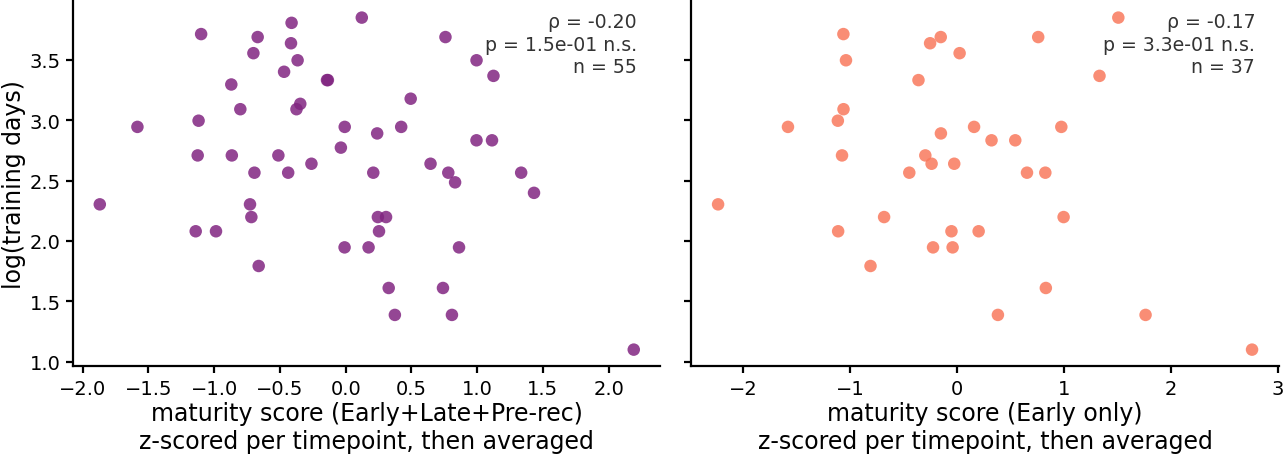

In [16]:
"""
ONE NUMBER PER MOUSE
====================
Instead of nine score-by-timepoint correlations, collapse everything into a single
per-mouse metric and test that once.

How the averaging is done, and why: the raw scores are not on a common scale (the
maturity projection is in profile units and its spread differs between timepoints,
the other two are correlations), so each score is Z-SCORED ACROSS MICE WITHIN ITS
TIMEPOINT first. Averaging raw values would silently weight whichever timepoint
happened to have the largest spread. After that a mouse's score is the mean over the
timepoints it actually has, so mice missing a timepoint are not dropped -- set
min_tps=len(TPS) if you would rather use complete cases only.

kind='maturity'        the projection onto the T -> Proficient direction (default)
kind='all'             maturity, stability and identifiability averaged together --
                       they all point the same way (higher = more proficient-like)
CHECK M.corr() BELOW FIRST: if the per-timepoint composites do not agree with each
other, a single average over them is not describing one thing.
"""
def _z(s):
    s = pd.Series(s, dtype=float)
    sd = s.std(ddof=1)
    return (s - s.mean()) / sd if sd and sd > 0 else s * np.nan


SCORE_FUNCS = {
    'maturity':        maturity_score,
    'stability':       signature_stability,
    'identifiability': lambda tp, **kw: identifiability(tp, **kw)['percentile'],
}


def combined_score(kind='maturity', tps=None, min_tps=1, features=None, epochs=None):
    """(one score per mouse, the per-timepoint composites it was averaged from)."""
    tps = list(TPS if tps is None else tps)
    kinds = list(SCORE_FUNCS) if kind == 'all' else [kind]
    per_tp = {}
    for tp in tps:
        parts = [_z(SCORE_FUNCS[k](tp, features=features, epochs=epochs)) for k in kinds]
        per_tp[tp] = pd.concat(parts, axis=1).mean(axis=1, skipna=True)
    M = pd.DataFrame(per_tp)
    out = M.mean(axis=1, skipna=True)
    out[M.notna().sum(axis=1) < min_tps] = np.nan
    return out.rename(f'{kind}_combined'), M


def perm_spearman(x, y, n_perm=2000, seed=0):
    """Spearman rho with a mouse-label permutation p, which does not assume normality
    and is the honest test at this n."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    rho = spearmanr(x, y)[0]
    rng = np.random.default_rng(seed)
    null = np.array([spearmanr(x, rng.permutation(y))[0] for _ in range(n_perm)])
    return float(rho), float((np.sum(np.abs(null) >= abs(rho)) + 1) / (n_perm + 1))


score, M = combined_score('maturity')
print("do the timepoints agree with each other? (Spearman between per-timepoint "
      "composites)")
print(M.corr(method='spearman').round(2).to_string())
print(f"\nmice per timepoint: " + ", ".join(f"{c} {M[c].notna().sum()}" for c in M.columns)
      + f"  |  combined score for {score.notna().sum()} mice")

print(f"\nSINGLE METRIC vs log(training_days)   [{2000} permutations]")
print(f"{'metric':38s} {'rho':>7s} {'p_perm':>8s} {'n':>5s}")
HEADLINE = {}
for kind in ['maturity', 'all']:
    for tps, tag in [(TPS, 'Early+Late+Pre-rec'), (['Early'], 'Early only')]:
        s, _ = combined_score(kind, tps=tps)
        d = pd.concat([s.rename('score'), LEARN.rename('y')], axis=1).dropna()
        rho, p = perm_spearman(d['score'], d['y'])
        HEADLINE[(kind, tag)] = (d, rho, p)
        print(f"{kind + ', ' + tag:38s} {rho:7.3f} {p:8.4f} {len(d):5d}"
              f"{'  *' if p < 0.05 else ''}")
print("Early only is the clean test: Late and Pre-rec are positioned in time by when\n"
      "the mouse finished learning, so their timing is entangled with the outcome.")

ps.reapply()
fig, axes = panels(1, 2, w=0.95, h=1.0, sharey=True)
for ax, key in zip(axes, [('maturity', 'Early+Late+Pre-rec'), ('maturity', 'Early only')]):
    d, rho, p = HEADLINE[key]
    ax.scatter(d['score'], d['y'], s=plt.rcParams['lines.markersize'] ** 2,
               color=COLORS['Early'] if 'Early only' in key else COLORS['Pre-rec'],
               alpha=0.85, edgecolors='none')
    # significance-gated fit and in-panel stats, as everywhere else in the paper
    ps.regline(ax, d['score'], d['y'], p < 0.05)
    annotate_rho(ax, rho, p, n=len(d), loc='upper right')
    ax.set_xlabel(f'maturity score ({key[1]})\nz-scored per timepoint, then averaged')
axes[0].set_ylabel('log(training days)')
note(fig, 'one score per mouse: is proficient-like early behaviour faster learning?')
fig.tight_layout()
ps.savefig(fig, 'sylcorr_maturity_combined', svg=True)
plt.show()

dates found for 510/512 sessions
                  min        max  count
tp                                     
Early      2019-11-04 2022-08-05     37
Late       2019-12-03 2022-08-23     49
Pre-rec    2020-01-02 2022-11-11     96
Proficient 2019-11-26 2023-03-15    328

  gap (days)  median  mice  pairs      Paw    Whisk     Lick
         1-4       2    72    498    0.717    0.817    0.830
        4-11       6    55    506    0.607    0.753    0.751
       11-31      21    40    272    0.309    0.497    0.570
       31-91      50    45    316    0.145    0.319    0.315
      91-181     126    13     80    0.023   -0.032    0.062

median days from each timepoint to Proficient: Early 75, Late 37, Pre-rec 7

modality   timepoint    observed  predicted  obs - pred
Paw        Early           0.053      0.100      -0.047
Paw        Late            0.148      0.226      -0.077
Paw        Pre-rec         0.523      0.522       0.001
Whisk      Early           0.210      0.176       0.035
Wh

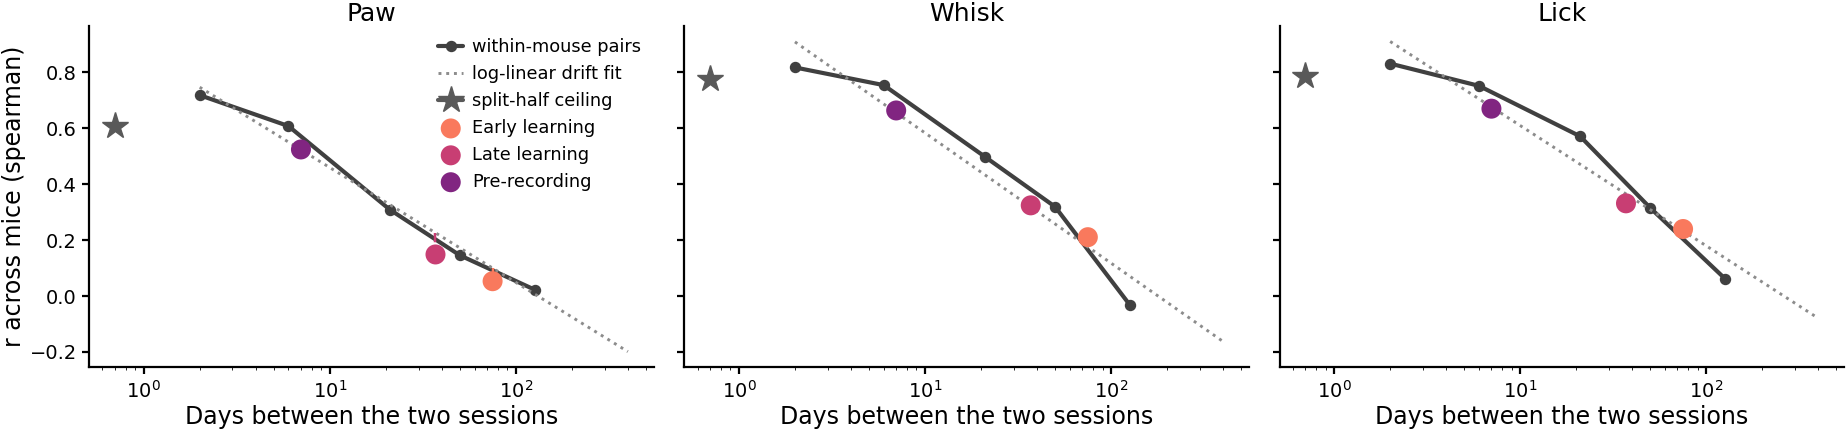


obs - pred < 0 means the timepoint is LESS similar to proficient than pure
elapsed-time drift accounts for -- the part that learning has to explain.


In [17]:
"""
HOW FAST DOES INDIVIDUALITY DECAY WITH TIME ALONE?
==================================================
The cross-timepoint correlations conflate two things: the mouse LEARNED, and time
PASSED. Session dates let them be separated without any new data.

Every within-mouse pair of sessions is grouped by how many days apart it is, and for
each gap bin the SAME across-mice correlation is computed -- earlier session of the
pair against later session, per (bin, syllable). That gives r as a function of
elapsed time, measured mostly inside the proficient block where no learning is going
on. Extrapolating that curve to the Early -> Proficient gap says how much of the low
Early correlation is explained by elapsed time alone; whatever sits BELOW the curve
is the part attributable to learning (or to the training rig, or to age).

Reading it:
  Early point ON the curve      the drop is just time passing, not learning
  Early point BELOW the curve   learning reorganised the behaviour beyond drift
  Early point ABOVE the curve   unlikely; suspect the date mapping
"""
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import load_session_table

_tab = load_session_table().drop_duplicates('eid')
DATES = pd.to_datetime(_tab.set_index('eid')['date'], errors='coerce')
sess_date = DATES.reindex(sessions)
print(f"dates found for {int(sess_date.notna().sum())}/{len(sessions)} sessions")

SESS = pd.DataFrame({'session': sessions, 'mouse': mice, 'tp': timepoint,
                     'date': sess_date.values, 'row': np.arange(len(sessions))}
                    ).dropna(subset=['date'])
print(SESS.groupby('tp')['date'].agg(['min', 'max', 'count']).to_string())

GAP_EDGES = (1, 4, 11, 31, 91, 181, 366, 100000)
MIN_MICE = 8


def decay_curve(gap_edges=GAP_EDGES, method=METHOD, min_mice=MIN_MICE):
    """r across mice between two sessions of the same mouse, as a function of the gap
    between them. A mouse contributing several pairs to a bin has its earlier and its
    later sessions averaged, so it counts once."""
    out = []
    for lo, hi in zip(gap_edges[:-1], gap_edges[1:]):
        A_rows, B_rows, gaps = {}, {}, []
        for m, g in SESS.groupby('mouse'):
            g = g.sort_values('date')
            dts = g['date'].values; rows = g['row'].values
            for i in range(len(g)):
                for j in range(i + 1, len(g)):
                    gap = (dts[j] - dts[i]) / np.timedelta64(1, 'D')
                    if lo <= gap < hi:
                        A_rows.setdefault(m, []).append(rows[i])
                        B_rows.setdefault(m, []).append(rows[j])
                        gaps.append(gap)
        ms = sorted(A_rows)
        if len(ms) < min_mice:
            continue
        A = np.stack([recon[A_rows[m]].mean(0) for m in ms])
        B = np.stack([recon[B_rows[m]].mean(0) for m in ms])
        r, _ = _corr_along_mice(A, B, method=method)
        out.append(dict(lo=lo, hi=hi, gap=float(np.median(gaps)), n_mice=len(ms),
                        n_pairs=len(gaps), r=r))
    return out


DECAY = decay_curve()
print(f"\n{'gap (days)':>12s} {'median':>7s} {'mice':>5s} {'pairs':>6s} "
      + " ".join(f"{m:>8s}" for m in MODALITIES))
for d in DECAY:
    hi = '+' if d['hi'] > 10000 else str(int(d['hi']))
    print(f"{str(int(d['lo'])) + '-' + hi:>12s} {d['gap']:7.0f} {d['n_mice']:5d} "
          f"{d['n_pairs']:6d} "
          + " ".join(f"{np.nanmean(d['r'][:, f]):8.3f}" for f in MODALITIES.values()))

# where do the cross-timepoint comparisons sit on this axis? median days from a
# mouse's sessions at T to its proficient sessions
tp_gap = {}
for tp in TPS:
    gs = []
    for m in CORR[tp]['mice']:
        a = SESS[(SESS.mouse == m) & (SESS.tp == tp)]['date']
        b = SESS[(SESS.mouse == m) & (SESS.tp == REF)]['date']
        if len(a) and len(b):
            gs.append((b.median() - a.median()) / np.timedelta64(1, 'D'))
    tp_gap[tp] = float(np.median(gs)) if gs else np.nan
print("\nmedian days from each timepoint to Proficient: "
      + ", ".join(f"{tp} {tp_gap[tp]:.0f}" for tp in TPS))


def plot_decay(w=0.9, h=0.95, save=None):
    ps.reapply()
    lw = plt.rcParams['lines.linewidth']
    ms = plt.rcParams['lines.markersize']
    fig, axes = panels(1, len(MODALITIES), w=w, h=h, sharey=True)
    axes = np.atleast_1d(axes)
    print(f"\n{'modality':10s} {'timepoint':11s} {'observed':>9s} {'predicted':>10s} "
          f"{'obs - pred':>11s}")
    for ax, (mod, feats) in zip(axes, MODALITIES.items()):
        x = np.array([d['gap'] for d in DECAY])
        y = np.array([np.nanmean(d['r'][:, feats]) for d in DECAY])
        ax.plot(x, y, 'o-', color='0.25', lw=lw, ms=ms * 0.8,
                label='within-mouse pairs')
        # log-linear fit through the drift points, extrapolated to the timepoint gaps
        ok = np.isfinite(x) & np.isfinite(y) & (x > 0)
        b = np.polyfit(np.log10(x[ok]), y[ok], 1) if ok.sum() > 2 else None
        if b is not None:
            xs = np.logspace(np.log10(max(x.min(), 1)), np.log10(max(x.max(), 400)), 50)
            ax.plot(xs, np.polyval(b, np.log10(xs)), ls=':', color='0.55', lw=lw * 0.7,
                    label='log-linear drift fit')
        ax.plot([0.7], [np.nanmean(CEIL['r'][:, feats])], marker='*', ms=ms * 2.2,
                color='0.35', label='split-half ceiling')
        for tp in TPS:
            obs = np.nanmean(CORR[tp]['r'][:, feats])
            ax.scatter([tp_gap[tp]], [obs], s=(ms * 1.6) ** 2, color=COLORS[tp],
                       zorder=5, edgecolors='none', label=TP_LABEL.get(tp, tp))
            pred = np.polyval(b, np.log10(tp_gap[tp])) if b is not None else np.nan
            ax.plot([tp_gap[tp], tp_gap[tp]], [pred, obs], color=COLORS[tp],
                    lw=lw * 0.6, ls='--')
            print(f"{mod:10s} {tp:11s} {obs:9.3f} {pred:10.3f} {obs - pred:11.3f}")
        ax.set_xscale('log'); ax.set_xlabel('Days between the two sessions')
        ax.set_title(mod)
    axes[0].set_ylabel(f'r across mice ({METHOD})')
    axes[0].legend(fontsize=small(0.8))
    note(fig, 'individuality vs elapsed time: is the early drop just drift?\n'
              'grey = pairs of sessions from the same mouse; coloured = the '
              'cross-timepoint comparisons at their true median gap')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_decay = plot_decay(save='sylcorr_decay_vs_time')
print("\nobs - pred < 0 means the timepoint is LESS similar to proficient than pure\n"
      "elapsed-time drift accounts for -- the part that learning has to explain.")

  Early         1732 (session x trial-type) cells
  Late          1922 (session x trial-type) cells
  Pre-rec       5024 (session x trial-type) cells
  Proficient   17141 (session x trial-type) cells
condition table: 25819 rows, 280 trial types

mean r across mice for each contrast (spearman, vs Proficient); 'level' is the plain profile from cell 2
contrast               modality      Early      Late   Pre-rec   ceiling     level
incorrect - correct    Paw           0.026     0.086     0.312     0.357     0.523
incorrect - correct    Whisk        -0.044     0.133     0.302     0.399     0.663
incorrect - correct    Lick          0.220     0.079     0.194     0.337     0.669
block 0.8 - 0.2        Paw             nan       nan     0.334     0.355     0.523
block 0.8 - 0.2        Whisk           nan       nan     0.309     0.275     0.663
block 0.8 - 0.2        Lick            nan       nan     0.385     0.275     0.669
left - right choice    Paw           0.028     0.099     0.427     0

/tmp/ipykernel_138349/70805213.py:164: RuntimeWarning: Mean of empty slice
  row = " ".join(f"{np.nanmean(CCORR[name][tp]['r'][:, feats]):9.3f}" for tp in TPS)
/tmp/ipykernel_138349/70805213.py:188: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Rr, axis=1)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


wrote figures/sylcorr_trial_type_contrasts_poster_14-09-2026.png, figures/sylcorr_trial_type_contrasts_poster_14-09-2026.svg


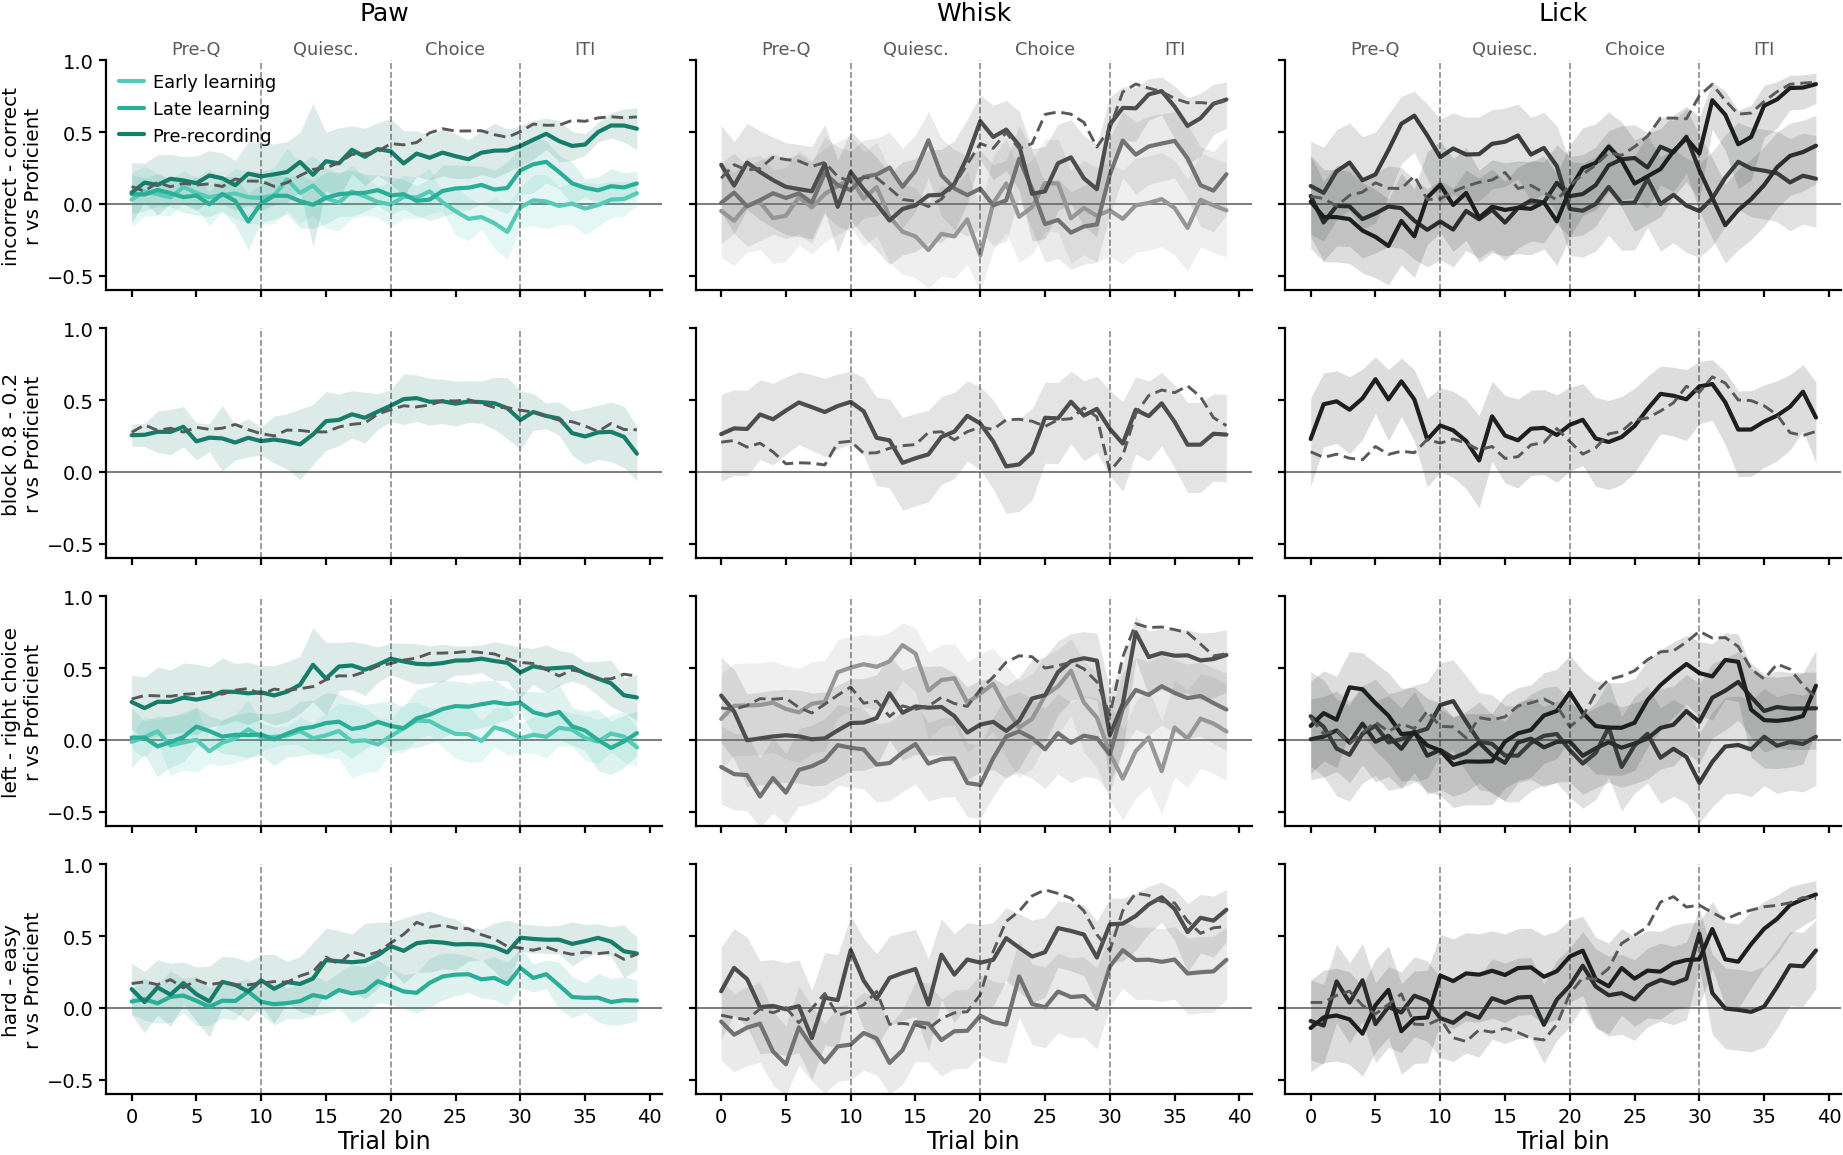

In [18]:
"""
TRIAL-TYPE CONTRASTS: IS THE MODULATION INDIVIDUAL, NOT JUST THE LEVEL?
=======================================================================
Everything above averages over trial types, so it measures how much of a syllable a
mouse uses. A contrast asks something a level cannot: does the mouse CHANGE its
behaviour between conditions in its own particular way -- more paw fidgeting after an
error, a different posture in the 80% block, and so on.

Contrasts are worth the trouble because a difference of two means from the same
session cancels anything that shifts the whole session together (a camera moved, the
rig, the mouse's weight that day), which is precisely the nuisance that inflates
level correlations. They cost reliability, though: a difference of two noisy means is
noisier than either, so each contrast gets its own split-half ceiling and the numbers
are only interpretable against it.

This cell re-reads the parquet files because the main build discards trial_type.
"""
FEAT_N = X.shape[1]


def build_condition_table(files=FILES, exclude_by_label=EXCLUDE_BY_LABEL):
    """One row per (timepoint, mouse, session, trial_type): mean binarised profile
    plus the number of trials behind it."""
    frames = []
    for label, path in files.items():
        seq = pd.read_parquet(path)
        seq['session'] = seq['sample'].str[:36]
        seq = filter_sequences(seq, min_sessions=1)
        drop = list(exclude_by_label.get(label, []))
        if drop:
            seq = seq.loc[~seq['session'].isin(drop)]
        design = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                            columns=['broader_label'], values='binned_sequence')
                  .reset_index().dropna())
        seqs = np.vstack(design[['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']]
                         .apply(lambda r: np.hstack(r), axis=1))
        feats = binarize(seqs, n_paw_states=N_PAW_STATES).astype(np.float32)
        t = pd.DataFrame(feats)
        t['timepoint'] = label
        t['mouse'] = design['mouse_name'].values
        t['session'] = design['session'].values
        t['trial_type'] = design['trial_type'].values
        g = t.groupby(['timepoint', 'mouse', 'session', 'trial_type'], sort=False)
        frames.append(g[list(range(feats.shape[1]))].mean().join(g.size().rename('n_trials')))
        print(f"  {label:11s} {len(frames[-1]):6d} (session x trial-type) cells")
    ct = pd.concat(frames).reset_index()
    parts = ct['trial_type'].str.split(' ', expand=True)
    assert parts.shape[1] == 4, f"unexpected trial_type format: {ct.trial_type.iloc[0]!r}"
    ct['outcome'] = parts[0]
    ct['contrast'] = pd.to_numeric(parts[1], errors='coerce')
    ct['block'] = parts[2]
    ct['choice'] = parts[3]
    ct['difficulty'] = np.select([ct['contrast'] >= 0.25, ct['contrast'] <= 0.0625],
                                 ['easy', 'hard'], default='mid')
    return ct


CT = build_condition_table()
print(f"condition table: {len(CT)} rows, {CT.trial_type.nunique()} trial types")
FEATCOLS = list(range(FEAT_N))


def reconstruct_diff(Xmat, n_paw_states=N_PAW_STATES):
    """reconstruct_syllables for a DIFFERENCE of profiles: the dropped paw state is
    -sum(others), not 1 - sum(others), because the constant cancels in a contrast."""
    npf = n_paw_states - 1 + 2
    T = Xmat.shape[1] // npf
    R = Xmat.reshape(-1, T, npf)
    paw7 = R[:, :, :n_paw_states - 1]
    full = np.zeros((Xmat.shape[0], T, n_paw_states + 2))
    full[:, :, 0] = paw7[:, :, 0]
    full[:, :, 1] = -paw7.sum(axis=2)
    full[:, :, 2:n_paw_states] = paw7[:, :, 1:]
    full[:, :, n_paw_states] = R[:, :, n_paw_states - 1]
    full[:, :, n_paw_states + 1] = R[:, :, n_paw_states]
    return full


CONTRASTS = {
    'incorrect - correct': ('outcome', 'incorrect', 'correct'),
    'block 0.8 - 0.2':     ('block', '0.8', '0.2'),
    'left - right choice': ('choice', 'left', 'right'),
    'hard - easy':         ('difficulty', 'hard', 'easy'),
}
MIN_TRIALS = 20          # per side, per mouse


def _wmean(sub):
    """trial-count-weighted mean over the selected rows, NaN-safe."""
    V = sub[FEATCOLS].to_numpy(dtype=float)
    w = sub['n_trials'].to_numpy(dtype=float)[:, None]
    num = np.nansum(np.where(np.isnan(V), 0.0, V) * w, axis=0)
    den = np.nansum(np.where(np.isnan(V), 0.0, w), axis=0)
    with np.errstate(invalid='ignore', divide='ignore'):
        return num / den


def contrast_profiles(name, tp, min_trials=MIN_TRIALS, keep_sessions=None):
    """(mice, (n_mice, n_bins, n_features)) of A-minus-B profiles at timepoint `tp`."""
    dim, a, b = CONTRASTS[name]
    d = CT[CT['timepoint'] == tp]
    if keep_sessions is not None:
        d = d[d['session'].isin(keep_sessions)]
    out = {}
    for m, g in d.groupby('mouse'):
        ga = g[g[dim] == a]; gb = g[g[dim] == b]
        if ga['n_trials'].sum() < min_trials or gb['n_trials'].sum() < min_trials:
            continue
        out[m] = _wmean(ga) - _wmean(gb)
    ms = np.array(sorted(out))
    if len(ms) == 0:
        return ms, np.zeros((0, N_BINS, recon.shape[2]))
    return ms, reconstruct_diff(np.stack([out[m] for m in ms]))


def contrast_corr(name, tp, ref=REF, method=METHOD):
    ms_a, A = contrast_profiles(name, tp)
    ms_b, B = contrast_profiles(name, ref)
    shared = np.intersect1d(ms_a, ms_b)
    if len(shared) < 6:
        return dict(r=np.full((N_BINS, recon.shape[2]), np.nan), n=len(shared))
    ia = pd.Index(ms_a).get_indexer(shared); ib = pd.Index(ms_b).get_indexer(shared)
    r, flat = _corr_along_mice(A[ia], B[ib], method=method)
    lo, hi = _fisher_ci(r, len(shared))
    lo[flat] = np.nan; hi[flat] = np.nan
    return dict(r=r, lo=lo, hi=hi, flat=flat, n=len(shared))


def contrast_ceiling(name, ref=REF, n_splits=50, method=METHOD, seed=0):
    """Split-half ceiling for a contrast: build it separately in each half of a
    mouse's proficient sessions, then correlate across mice."""
    sel = timepoint == ref
    by_mouse = {m: sessions[sel & (mice == m)] for m in np.unique(mice[sel])}
    by_mouse = {m: s for m, s in by_mouse.items() if len(s) >= 2}
    if len(by_mouse) < 6:
        return np.full((N_BINS, recon.shape[2]), np.nan)
    rng = np.random.default_rng(seed)
    zs = []
    for _ in range(n_splits):
        ha, hb = [], []
        for m, s in by_mouse.items():
            p = rng.permutation(s); k = len(s) // 2
            ha += list(p[:k]); hb += list(p[k:])
        ms_a, A = contrast_profiles(name, ref, keep_sessions=set(ha))
        ms_b, B = contrast_profiles(name, ref, keep_sessions=set(hb))
        shared = np.intersect1d(ms_a, ms_b)
        if len(shared) < 6:
            continue
        ia = pd.Index(ms_a).get_indexer(shared); ib = pd.Index(ms_b).get_indexer(shared)
        r, _ = _corr_along_mice(A[ia], B[ib], method=method)
        zs.append(np.arctanh(np.clip(r, -0.999999, 0.999999)))
    return np.tanh(np.nanmean(zs, axis=0)) if zs else np.full((N_BINS, recon.shape[2]), np.nan)


CCORR = {name: {tp: contrast_corr(name, tp) for tp in TPS} for name in CONTRASTS}
CCEIL = {name: contrast_ceiling(name) for name in CONTRASTS}

print(f"\nmean r across mice for each contrast ({METHOD}, vs {REF}); "
      f"'level' is the plain profile from cell 2")
print(f"{'contrast':22s} {'modality':9s} " + " ".join(f"{tp:>9s}" for tp in TPS)
      + f" {'ceiling':>9s} {'level':>9s}")
for name in CONTRASTS:
    for mod, feats in MODALITIES.items():
        row = " ".join(f"{np.nanmean(CCORR[name][tp]['r'][:, feats]):9.3f}" for tp in TPS)
        print(f"{name:22s} {mod:9s} {row} "
              f"{np.nanmean(CCEIL[name][:, feats]):9.3f} "
              f"{np.nanmean(CORR[TPS[-1]]['r'][:, feats]):9.3f}")
print("mice per contrast: " + ", ".join(
    f"{name} [" + "/".join(str(CCORR[name][tp]['n']) for tp in TPS) + "]" for name in CONTRASTS))


def plot_contrasts(names=None, tps=None, show_ci=True, ylim=(-0.6, 1.0),
                   w=0.9, h=0.6, save=None):
    ps.reapply()
    names = list(CONTRASTS if names is None else names)
    tps = list(TPS if tps is None else tps)
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']
    fig, axes = panels(len(names), len(MODALITIES), w=w, h=h, squeeze=False,
                       sharex=True, sharey=True)
    for r_i, name in enumerate(names):
        for c_i, (mod, feats) in enumerate(MODALITIES.items()):
            ax = axes[r_i][c_i]
            for tp in tps:
                C = CCORR[name][tp]
                col = shade(FEATURE_COLORS[feats[0]], tp_weight(tp, tps))
                Rr = C['r'][:, feats]
                mu = np.nanmean(Rr, axis=1)
                ax.plot(bins, mu, color=col, lw=lw, label=TP_LABEL.get(tp, tp))
                if show_ci:
                    # the Paw panel plots the MEAN of 8 states, and a Fisher CI on a
                    # mean of 8 correlated r's is not a valid interval -- so the band
                    # there is the spread ACROSS the states. Whisk and Lick are single
                    # syllables and get their real Fisher 95% CI.
                    if len(feats) == 1 and 'lo' in C:
                        lo, hi = C['lo'][:, feats[0]], C['hi'][:, feats[0]]
                    else:
                        sd = np.nanstd(Rr, axis=1)
                        lo, hi = mu - sd, mu + sd
                    ax.fill_between(bins, lo, hi, color=col, alpha=0.15, lw=0)
            ax.plot(bins, np.nanmean(CCEIL[name][:, feats], axis=1), color='0.35',
                    ls=(0, (4, 2)), lw=lw * 0.7)
            _epoch_furniture(ax, label_epochs=(r_i == 0))
            if r_i == 0:
                panel_title(ax, mod, above_epochs=True)
            if c_i == 0:
                ax.set_ylabel(f"{name}\nr vs {REF}", fontsize=small(0.9))
            ax.set_ylim(*ylim)
    for ax in axes[-1]:
        ax.set_xlabel('Trial bin')
    axes[0][0].legend(fontsize=small(0.8))
    note(fig, "is a mouse's MODULATION between trial types individual, and preserved?\n"
              "dashed = split-half ceiling for that contrast; band = Fisher 95% CI "
              "(Whisk, Lick) or spread across the 8 paw states (Paw)")
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_contrasts = plot_contrasts(save='sylcorr_trial_type_contrasts')

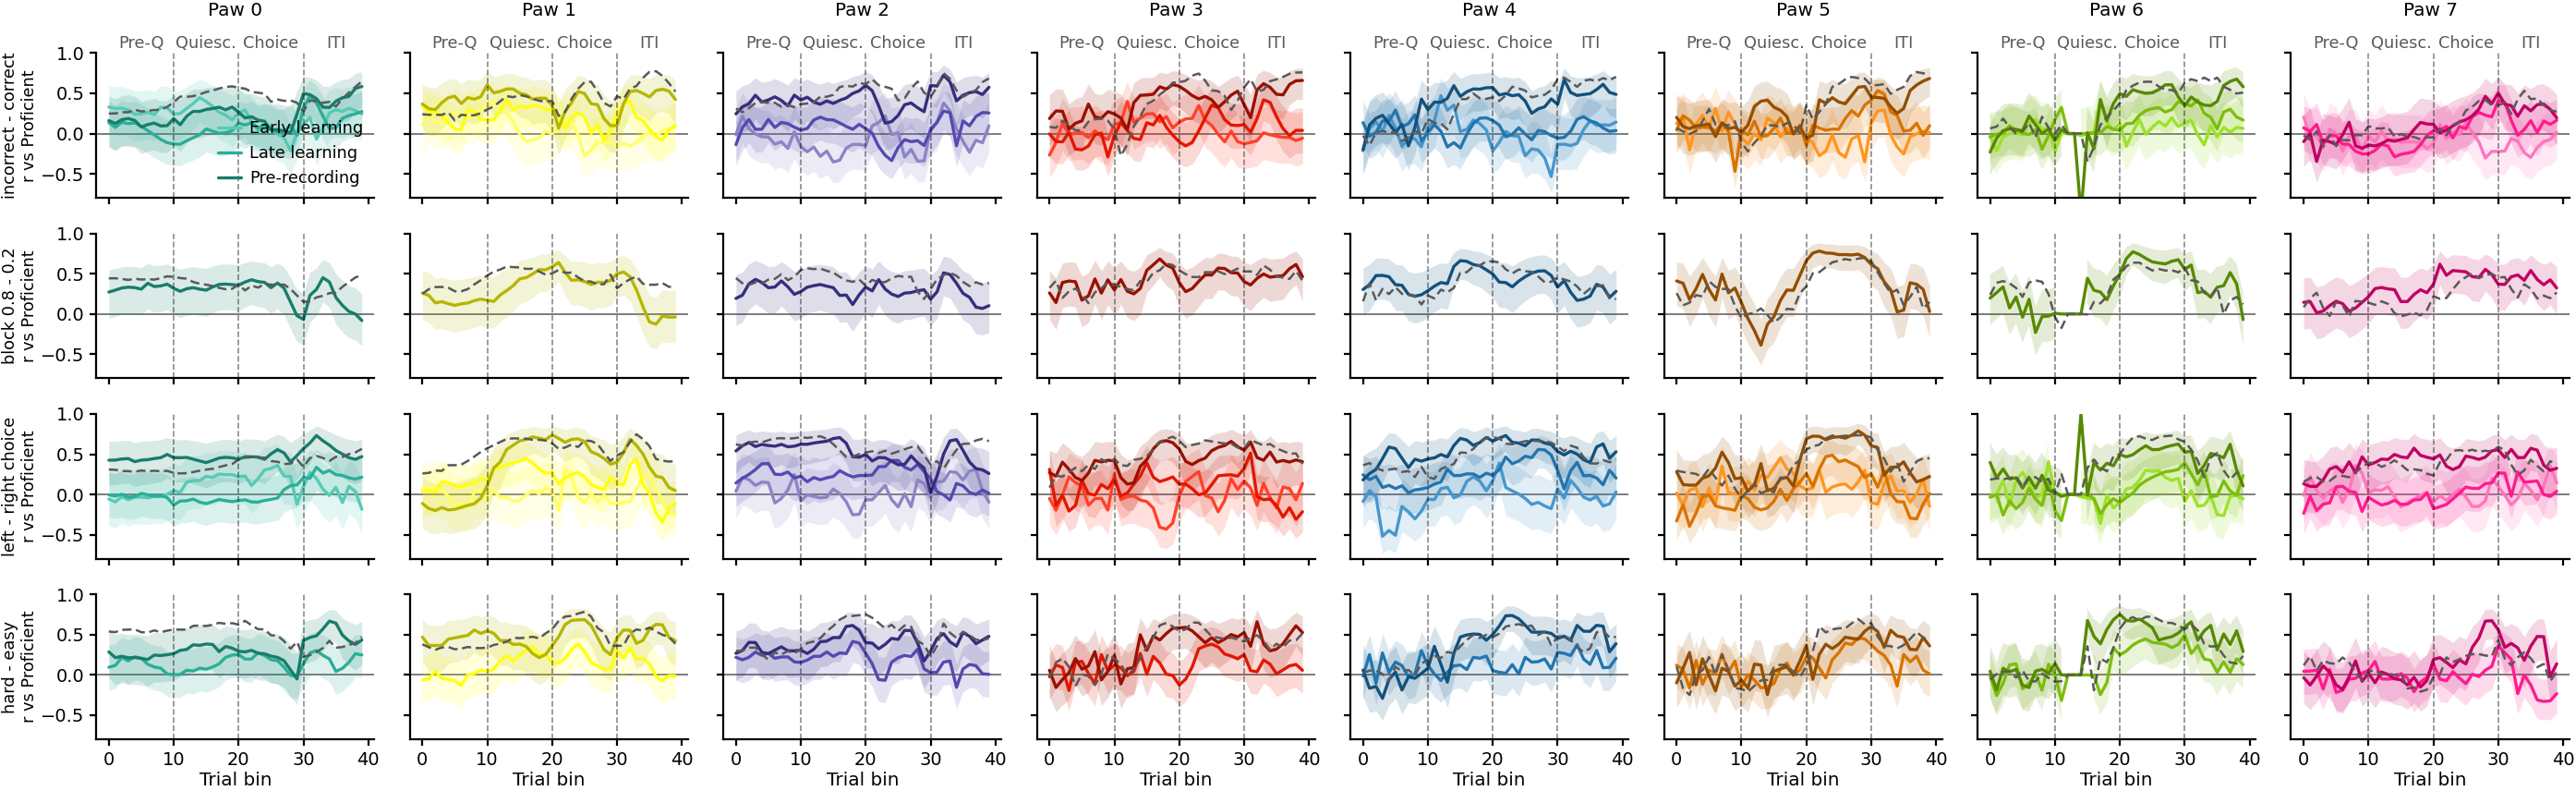

In [19]:
""" THE PAW PANEL UNFOLDED: one column per paw state, one row per contrast.
    Every panel is a single syllable, so every band here is a real Fisher 95% CI on
    r -- which is what the collapsed Paw panel above cannot show.

    This is a 32-panel diagnostic grid, not a poster figure: the panels are ~0.45 of
    a paper_style single panel and it is not saved by default (pass save='name'). """
def plot_contrasts_by_feature(names=None, features=None, tps=None, show_ci=True,
                              show_ceiling=True, ylim=(-0.8, 1.0), w=0.5, h=0.45,
                              save=None):
    ps.reapply()
    names = list(CONTRASTS if names is None else names)
    features = ([f'Paw {i}' for i in range(N_PAW_STATES)] if features is None
                else list(features))
    idx = [FEATURE_NAMES.index(f) for f in features]
    tps = list(TPS if tps is None else tps)
    bins = np.arange(N_BINS)
    lw = plt.rcParams['lines.linewidth']
    fig, axes = panels(len(names), len(idx), w=w, h=h, squeeze=False,
                       sharex=True, sharey=True)
    for r_i, name in enumerate(names):
        for c_i, j in enumerate(idx):
            ax = axes[r_i][c_i]
            for tp in tps:
                C = CCORR[name][tp]
                col = shade(FEATURE_COLORS[j], tp_weight(tp, tps))
                ax.plot(bins, C['r'][:, j], color=col, lw=lw * 0.8,
                        label=TP_LABEL.get(tp, tp) if (r_i == 0 and c_i == 0) else None)
                if show_ci and 'lo' in C:
                    ax.fill_between(bins, C['lo'][:, j], C['hi'][:, j],
                                    color=col, alpha=0.16, lw=0)
            if show_ceiling:
                ax.plot(bins, CCEIL[name][:, j], color='0.35', ls=(0, (4, 2)),
                        lw=lw * 0.6)
            _epoch_furniture(ax, label_epochs=(r_i == 0))
            if r_i == 0:
                panel_title(ax, FEATURE_NAMES[j], above_epochs=True,
                            fontsize=small(0.9))
            if c_i == 0:
                ax.set_ylabel(f"{name}\nr vs {REF}", fontsize=small(0.8))
            ax.set_ylim(*ylim)
    for ax in axes[-1]:
        ax.set_xlabel('Trial bin', fontsize=small(0.9))
    axes[0][0].legend(fontsize=small(0.8))
    note(fig, 'trial-type contrasts, one panel per paw state  '
              "(band = Fisher 95% CI, dashed = that contrast's split-half ceiling)")
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


fig_contrast_paws = plot_contrasts_by_feature()

wrote figures/sylcorr_contrasts_whisk_lick_poster_14-09-2026.png, figures/sylcorr_contrasts_whisk_lick_poster_14-09-2026.svg


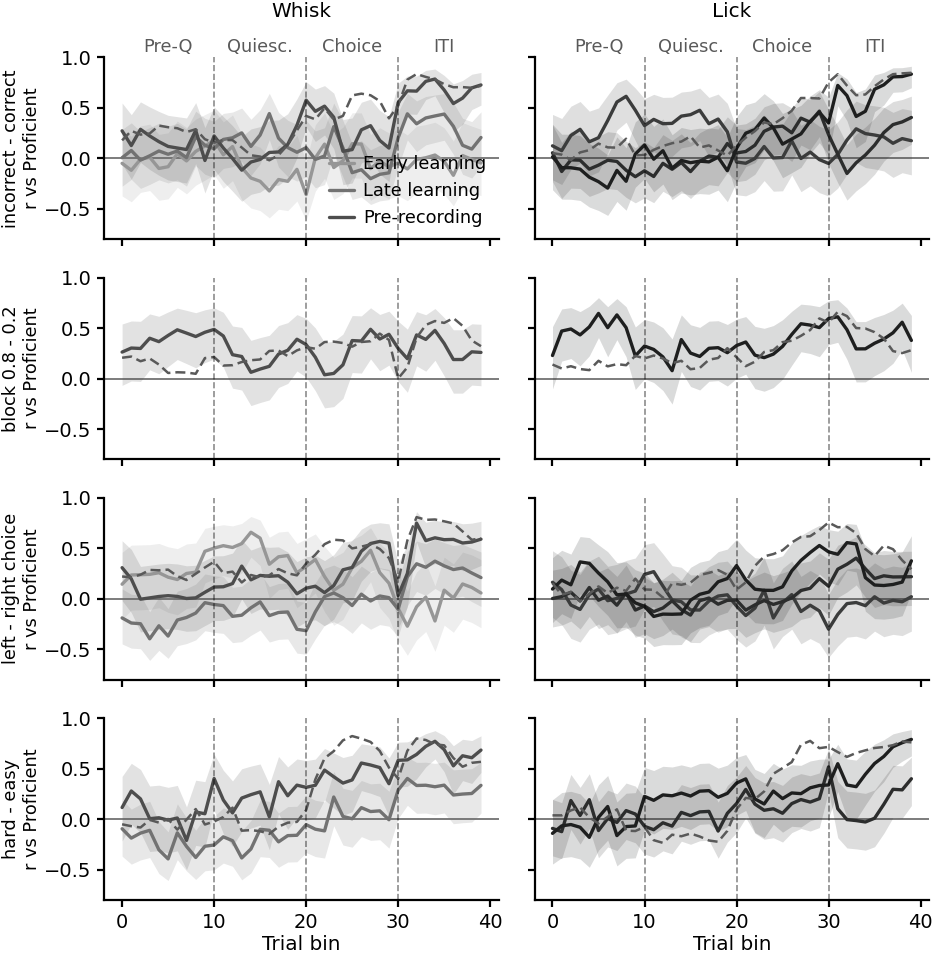

In [20]:
""" the same unfolding for whisk and lick, and for one contrast at a time if the
    32-panel grid is too much: plot_contrasts_by_feature(names=['hard - easy']) """
fig_contrast_wl = plot_contrasts_by_feature(features=['Whisk', 'Lick'], w=0.7, h=0.5,
                                            save='sylcorr_contrasts_whisk_lick')

1714 within-mouse session pairs from 76 mice | metric = r (similarity)
            pairs  median_days  median_value
tp_a                                        
Early         239         68.0        -0.066
Late          311         37.0         0.138
Pre-rec       524          6.0         0.431
Proficient    640          3.0         0.643
different mice, same timepoint (median): 0.207
same mouse, closest-in-time pair (median): 0.620

pooled Spearman(days, r) = -0.579  p = 3.02e-154  (n = 1714 pairs, NOT independent)
per-mouse Spearman: median -0.643, IQR [-0.839, -0.362]
   56/58 mice in the expected direction (similarity falling with time), sign test p = 1.19e-14

by dataset of the earlier session in the pair
earlier       pairs     rho         p
Early           239  -0.253  7.45e-05
Late            311  -0.152   0.00712
Pre-rec         524  -0.185  1.99e-05
Proficient      640  -0.113   0.00431
   x truncated at 100 days: 106 of 1714 pairs dropped (6%); rho and the fit describe the p

/tmp/ipykernel_138349/1549177745.py:143: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: spearmanr(g['days'], g['value'])[0] if len(g) >= 3 else np.nan)


wrote figures/sylcorr_similarity_vs_time_poster_14-09-2026.png, figures/sylcorr_similarity_vs_time_poster_14-09-2026.svg


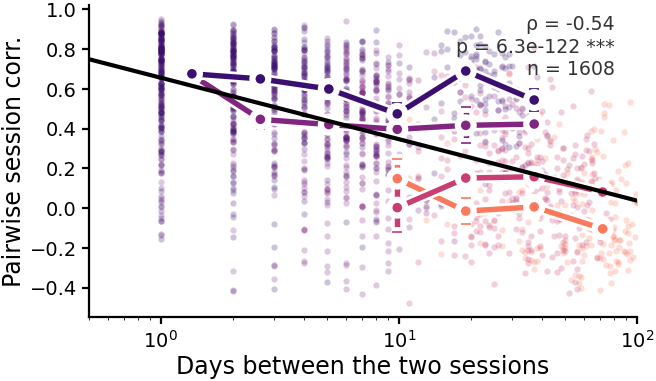

In [41]:
import matplotlib.patheffects as pe

"""
PAIR-LEVEL: BEHAVIOURAL SIMILARITY (OR DISTANCE) vs TIME DISTANCE
=================================================================
One dot per PAIR OF SESSIONS FROM THE SAME MOUSE: x = how many days apart, y = how
alike the behaviour is. Colour = the dataset the EARLIER session of the pair belongs
to, so a pair that starts in Early and ends in Proficient is orange, a pair of two
proficient sessions is blue, and so on.

PAIR_METRIC picks what y means, and therefore which way the cloud tilts:
  'r'           the correlation between the two sessions' deviation profiles. Falls
                with time, from the split-half level down toward 0. This is the
                natural axis for "individuality decays".
  'correlation' 1 - r, the distance version of exactly the same number: rises.
  'euclidean'   L2 distance in z units; rises, and also responds to overall
                magnitude rather than pattern alone.

Landmarks on the y axis, both drawn: the median value for pairs of DIFFERENT mice at
the same timepoint (r ~ 0, i.e. "as unalike as two different animals"), and the
same-mouse same-session split-half level, which is the ceiling any pair could reach.

TWO STATISTICS, because pairs are not independent -- one mouse with 6 sessions
contributes 15 pairs:
  pooled Spearman     over all pairs; fine for description, its p is anticonservative
  per-mouse Spearman  computed within each mouse, then summarised across mice. That
                      is the honest test, and the sign test across mice is its p.
"""
PAIR_METRIC = 'r'                # 'r' | 'correlation' | 'euclidean'  (see above)
ZSCORE_FEATURES = True           # standardise each feature over all sessions first,
                                 # so a high-variance syllable does not set the metric
METRIC_LABEL = {'r': 'behavioural similarity  (r between sessions)',
                'correlation': 'behavioural distance  (1 - r)',
                'euclidean': 'behavioural distance  (euclidean, z units)'}
IS_SIMILARITY = {'r': True, 'correlation': False, 'euclidean': False}

# needs SESS from the decay cell above; rebuilt here if that cell was not run
if 'SESS' not in globals():
    from session_filters import load_session_table
    _tab = load_session_table().drop_duplicates('eid')
    DATES = pd.to_datetime(_tab.set_index('eid')['date'], errors='coerce')
    SESS = pd.DataFrame({'session': sessions, 'mouse': mice, 'tp': timepoint,
                         'date': DATES.reindex(sessions).values,
                         'row': np.arange(len(sessions))}).dropna(subset=['date'])


def session_features(zscore=ZSCORE_FEATURES, metric=PAIR_METRIC):
    """(n_sessions, n_cells), plus a row-standardised copy for the correlation metrics.

    The per-cell z-score across sessions is what makes this a comparison of
    DEVIATIONS: subtracting each cell's grand mean removes the task-locked structure
    every session shares, which would otherwise make all sessions look alike.
    """
    F = recon.reshape(len(recon), -1).astype(float)
    if zscore:
        sd = np.nanstd(F, axis=0)
        F = (F - np.nanmean(F, axis=0)) / np.where(sd > 1e-12, sd, np.inf)
    Fz = None
    if metric in ('r', 'correlation'):
        mu = F.mean(1, keepdims=True); s = F.std(1, keepdims=True)
        Fz = (F - mu) / np.where(s > 1e-12, s, np.inf)
    return F, Fz


F_SESS, F_SESSZ = session_features()


def pair_value(I, J, metric=PAIR_METRIC):
    """The y quantity for the session pairs (rows I) x (rows J)."""
    if metric in ('r', 'correlation'):
        r = np.einsum('ij,ij->i', F_SESSZ[I], F_SESSZ[J]) / F_SESSZ.shape[1]
        return r if metric == 'r' else 1 - r
    return np.linalg.norm(F_SESS[I] - F_SESS[J], axis=1)


def within_mouse_pairs():
    """Every same-mouse pair of sessions: gap in days, y value, and the dataset of
    the earlier and later member."""
    rec = []
    for m, g in SESS.groupby('mouse'):
        g = g.sort_values('date')
        d = g['date'].values; rows = g['row'].values; tps = g['tp'].values
        for i in range(len(g)):
            for j in range(i + 1, len(g)):
                rec.append((m, (d[j] - d[i]) / np.timedelta64(1, 'D'),
                            rows[i], rows[j], tps[i], tps[j]))
    P = pd.DataFrame(rec, columns=['mouse', 'days', 'row_a', 'row_b', 'tp_a', 'tp_b'])
    P['value'] = pair_value(P['row_a'].values, P['row_b'].values)
    P['cross'] = P['tp_a'] != P['tp_b']
    # same-day pairs cannot be shown on a log axis; parked at half a day
    P['days_plot'] = np.where(P['days'] < 0.5, 0.5, P['days'])
    return P


PAIRS = within_mouse_pairs()
print(f"{len(PAIRS)} within-mouse session pairs from {PAIRS.mouse.nunique()} mice "
      f"| metric = {PAIR_METRIC} ({'similarity' if IS_SIMILARITY[PAIR_METRIC] else 'distance'})")
print(PAIRS.groupby('tp_a').agg(pairs=('days', 'size'), median_days=('days', 'median'),
                                median_value=('value', 'median')).round(3).to_string())


def between_mouse_reference(n_sample=4000, seed=0):
    """Median value for pairs of DIFFERENT mice at the SAME timepoint."""
    rng = np.random.default_rng(seed)
    vs = []
    for tp in ALL_ORDER:
        rows = SESS.loc[SESS.tp == tp, 'row'].values
        mus = SESS.loc[SESS.tp == tp, 'mouse'].values
        if len(rows) < 4:
            continue
        a = rng.integers(0, len(rows), n_sample); b = rng.integers(0, len(rows), n_sample)
        ok = mus[a] != mus[b]
        if ok.sum():
            vs.append(pair_value(rows[a[ok]], rows[b[ok]]))
    return float(np.median(np.concatenate(vs))) if vs else np.nan


def within_session_reference(n_pairs_per_mouse=None, seed=0):
    """The ceiling: same mouse, SAME session compared with itself is degenerate, so
    the nearest honest thing is the closest-in-time pair each mouse has (usually
    consecutive days). Reported as the median over mice."""
    vals = []
    for m, g in SESS.groupby('mouse'):
        g = g.sort_values('date')
        if len(g) < 2:
            continue
        d = g['date'].values; rows = g['row'].values
        gaps = [( (d[j] - d[i]) / np.timedelta64(1, 'D'), rows[i], rows[j])
                for i in range(len(g)) for j in range(i + 1, len(g))]
        gaps.sort(key=lambda t: t[0])
        vals.append(pair_value(np.array([gaps[0][1]]), np.array([gaps[0][2]]))[0])
    return float(np.median(vals)) if vals else np.nan


BETWEEN = between_mouse_reference()
NEAREST = within_session_reference()
print(f"different mice, same timepoint (median): {BETWEEN:.3f}")
print(f"same mouse, closest-in-time pair (median): {NEAREST:.3f}")

# ---- statistics ----
rho_all, p_all = spearmanr(PAIRS['days'], PAIRS['value'])
per_mouse = (PAIRS.groupby('mouse')
             .apply(lambda g: spearmanr(g['days'], g['value'])[0] if len(g) >= 3 else np.nan)
             .dropna())
EXPECT = -1 if IS_SIMILARITY[PAIR_METRIC] else 1     # similarity should FALL with time
good = int(((per_mouse * EXPECT) > 0).sum()); tot = len(per_mouse)
from scipy.stats import binomtest
sign_p = binomtest(good, tot, 0.5).pvalue if tot else np.nan
print(f"\npooled Spearman(days, {PAIR_METRIC}) = {rho_all:+.3f}  p = {p_all:.3g}  "
      f"(n = {len(PAIRS)} pairs, NOT independent)")
print(f"per-mouse Spearman: median {per_mouse.median():+.3f}, "
      f"IQR [{per_mouse.quantile(.25):+.3f}, {per_mouse.quantile(.75):+.3f}]")
print(f"   {good}/{tot} mice in the expected direction "
      f"({'similarity falling' if EXPECT < 0 else 'distance rising'} with time), "
      f"sign test p = {sign_p:.3g}")
print("\nby dataset of the earlier session in the pair")
print(f"{'earlier':12s} {'pairs':>6s} {'rho':>7s} {'p':>9s}")
for tp in ALL_ORDER:
    s = PAIRS[PAIRS.tp_a == tp]
    if len(s) > 5:
        r, pv = spearmanr(s['days'], s['value'])
        print(f"{tp:12s} {len(s):6d} {r:+7.3f} {pv:9.3g}")


def time_bins(x_max, log_x, n=8):
    """Bin edges spanning the range ACTUALLY PLOTTED, so the binning follows the axis.

    Geometric edges on a log axis, linear edges on a linear one -- log-spaced bins on a
    linear axis (what the fixed tuple used to give) crowd every early bin into the first
    few pixels and leave the last bin covering half the panel.
    """
    lo = 0.5
    if log_x:
        return np.geomspace(lo, x_max, n + 1)
    return np.linspace(lo, x_max, n + 1)


def plot_value_vs_time(pairs=PAIRS, log_x=True, show_fits=True, bins=None,
                       x_max=100, w=1, h=.85, save=None):
    """Scatter of every within-mouse session pair, WITH the binned medians overlaid.

    x_max truncates the axis (None = no truncation). Pairs beyond it are DROPPED, not
    just clipped: the fit and the rho quoted in the panel describe the range on display,
    which they would not if far-apart pairs still pulled the line while sitting off-panel.
    The bin edges are rebuilt from the same range -- see time_bins.
    """
    ps.reapply()
    lw = plt.rcParams['lines.linewidth']
    ms = plt.rcParams['lines.markersize']

    n_all = len(pairs)
    if x_max is not None:
        pairs = pairs[pairs['days_plot'] <= x_max]
    n_drop = n_all - len(pairs)
    hi = x_max if x_max is not None else pairs['days_plot'].max()
    if bins is None:
        bins = time_bins(hi, log_x)
    bins = np.asarray(bins, dtype=float)

    rho_p, p_p = spearmanr(pairs['days'], pairs['value'])
    fig, ax = panels(1, 1, w=w, h=h)

    # --- the cloud: every pair, coloured by the earlier session's dataset ---
    for tp in ALL_ORDER:
        sub = pairs[pairs.tp_a == tp]
        if not len(sub):
            continue
        ax.scatter(sub['days_plot'], sub['value'], s=(ms * 0.5) ** 2, alpha=0.25,
                   linewidth=0, color=COLORS[tp], zorder=1)

    # --- overlaid: the binned medians that used to live in a second panel ---
    # drawn on top of the cloud in the same colours, with a white outline so the line
    # stays readable where the dots are densest
    centres = (np.sqrt(bins[:-1] * bins[1:]) if log_x
               else 0.5 * (bins[:-1] + bins[1:]))
    for tp in ALL_ORDER:
        sub = pairs[pairs.tp_a == tp]
        if len(sub) < 5:
            continue
        idx = np.digitize(sub['days_plot'], bins) - 1
        xs, ys, es = [], [], []
        for k in range(len(bins) - 1):
            v = sub.loc[idx == k, 'value']
            if len(v) >= 3:
                xs.append(centres[k]); ys.append(v.median())
                es.append(1.253 * v.std(ddof=1) / np.sqrt(len(v)))   # SE of a median
        if xs:
            ax.errorbar(xs, ys, yerr=es, fmt='o-', color=COLORS[tp], lw=lw * 1.3,
                        ms=ms * 0.9, zorder=3,
                        markeredgecolor='white', markeredgewidth=lw * 0.4,
                        path_effects=[pe.Stroke(linewidth=lw * 2.6, foreground='white'),
                                      pe.Normal()],
                        label=f'{TP_LABEL.get(tp, tp)}  ({len(sub)} pairs)')

    if show_fits:
        ok = pairs['days_plot'] > 0
        xv = np.log10(pairs.loc[ok, 'days_plot']) if log_x else pairs.loc[ok, 'days_plot']
        b = np.polyfit(xv, pairs.loc[ok, 'value'], 1)
        xs = (np.geomspace(0.5, hi, 50) if log_x else np.linspace(0.5, hi, 50))
        ax.plot(xs, np.polyval(b, np.log10(xs) if log_x else xs), color='k', lw=lw,
                zorder=4, label='linear fit, all pairs')

    if log_x:
        ax.set_xscale('log')
    ax.set_xlim(0.5 if log_x else 0, hi)
    ax.set_xlabel('Days between the two sessions')
    ax.set_ylabel('Pairwise session corr.')
    # panel_title(ax, f'within-mouse session pairs (n = {len(pairs)})',
    #             fontsize=small(0.95))
    if n_drop:
        print(f'   x truncated at {x_max:g} days: {n_drop} of {n_all} pairs dropped '
              f'({n_drop / n_all:.0%}); rho and the fit describe the plotted range only')
    annotate_rho(ax, rho_p, p_p, n=len(pairs),
                 loc='upper right' if IS_SIMILARITY[PAIR_METRIC] else 'upper left')
    # outside the axes: with the cloud filling the panel there is no free corner, and
    # the stats block already owns one of them
    # ax.legend(fontsize=small(0.75), loc='center left', bbox_to_anchor=(1.01, 0.5),
    #           frameon=False)

    note(fig, f'{METRIC_LABEL[PAIR_METRIC]} against time distance, one dot per session '
              'pair;\nlines = binned medians +/- SE. same line = pure drift; '
              'offset lines = the dataset itself matters')
    fig.tight_layout()
    if save:
        ps.savefig(fig, save, svg=True)
    plt.show()
    return fig


# kept as an alias so the cell below (same-timepoint pairs only) still works
# plot_distance_vs_time = plot_value_vs_time

fig_value_time = plot_value_vs_time(log_x=True, save='sylcorr_similarity_vs_time')

   x truncated at 100 days: 106 of 1714 pairs dropped (6%); rho and the fit describe the plotted range only
wrote figures/sylcorr_similarity_vs_time_poster_14-09-2026.png, figures/sylcorr_similarity_vs_time_poster_14-09-2026.svg


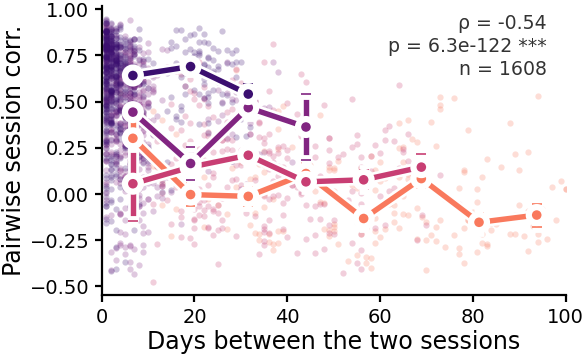

In [43]:
fig_value_time = plot_value_vs_time(log_x=False, x_max=100, w=.9, h=.8, show_fits=False, bins=None, save='sylcorr_similarity_vs_time')

   x truncated at 100 days: 2 of 724 pairs dropped (0%); rho and the fit describe the plotted range only
wrote figures/sylcorr_similarity_vs_time_within_poster_14-09-2026.png, figures/sylcorr_similarity_vs_time_within_poster_14-09-2026.svg


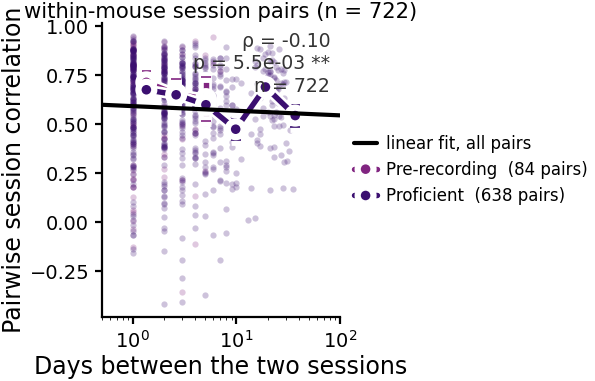

In [22]:
""" Same-timepoint pairs only: no learning stage is crossed, so this is drift and
    nothing else -- the reference against which the cross-dataset pairs are read. """
fig_dist_time_within = plot_value_vs_time(PAIRS[~PAIRS['cross']],
                                          save='sylcorr_similarity_vs_time_within')